# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from scipy.stats import wilcoxon
import yfinance as yf

from aux import evaluate_dummy_majority_cv, evaluate_model_cv, wilcoxon_comparison, bootstrap_comparison, get_oof_predictions, evaluate_by_group, plot_calls_metric, plot_group_bars

from multimodal_fin.financial.pipeline import EventPipeline
from multimodal_fin.financial.price_preprocessor import PricePreprocessor

# Load data

In [ ]:
X_all = pd.read_parquet("X_all.parquet")
y_all = pd.read_parquet("y_all.parquet").squeeze()
row_info_all = pd.read_parquet("row_info_all.parquet")

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

X_all shape: (31505, 67)
y_all shape: (31505,)


In [3]:
X_all

,text_emo_happy,text_emo_neutral,text_emo_surprise,text_emo_disgust,text_emo_anger,text_emo_sadness,text_emo_fear,audio_emo_happy,audio_emo_neutral,audio_emo_surprise,...,answer_pca_11,answer_pca_12,answer_pca_13,answer_pca_14,answer_pca_15,answer_pca_16,answer_pca_17,answer_pca_18,answer_pca_19,topic_qa_match
0,3.924768,1.058172,-0.096306,-0.422651,-0.850437,-1.454606,-2.158941,0.662840,6.753231,-6.740687,...,-0.137906,-0.071568,0.052837,-0.029923,-0.097494,0.066620,-0.074613,-0.031130,-0.060551,1.0
1,4.109834,1.202542,-0.140497,-0.638633,-1.012647,-1.506743,-2.013856,4.219045,7.482748,-4.962939,...,0.222383,0.058768,0.064813,-0.011871,-0.029200,-0.159744,0.113788,-0.092028,0.022976,0.0
2,4.187207,0.546458,-0.207523,-0.623803,-0.962683,-1.250079,-1.689577,-0.102574,7.542330,-5.894590,...,0.125432,-0.098448,0.113951,-0.062496,-0.144137,-0.071044,0.064981,-0.133804,0.002147,0.0
3,3.812585,0.703028,-0.090554,-0.523612,-1.033350,-1.257127,-1.610970,1.691575,8.330901,-5.915460,...,-0.080961,0.096887,-0.143388,-0.068030,-0.028538,-0.138915,0.135440,-0.116026,-0.033694,0.0
4,4.211723,0.333905,-0.195785,-0.447855,-0.728834,-1.349902,-1.823252,0.697968,6.956728,-7.321293,...,-0.192063,-0.185675,-0.022280,0.089676,-0.008549,-0.046287,-0.017276,0.081603,0.096997,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31500,4.105245,0.764914,-0.088506,-0.679014,-0.954324,-1.263053,-1.885263,1.834586,8.183475,-6.388152,...,0.109090,0.150886,0.111550,-0.104709,0.103487,0.170613,0.041611,-0.130614,-0.121063,1.0
31501,3.559616,1.574061,0.286221,-0.462519,-1.075626,-1.593840,-2.287915,2.903805,9.935278,-6.630977,...,-0.073771,0.166921,-0.112704,-0.014120,0.102164,-0.077429,-0.163999,-0.174103,-0.167357,0.0
31502,3.652608,1.269817,0.069067,-0.555104,-0.945977,-1.418331,-2.072080,0.919626,9.976890,-7.344946,...,-0.325526,-0.226101,0.048105,0.013728,0.010355,0.077671,-0.036298,0.086482,0.050816,1.0
31503,3.512665,0.978318,-0.012903,-0.514765,-0.863579,-1.357320,-1.742416,0.564162,10.428622,-6.873766,...,0.145913,0.116343,0.018690,-0.044534,-0.060469,-0.068596,-0.045778,0.102208,-0.144662,0.0


In [4]:
row_info_all

,company,year,conference,pair_id,answered,question,answer,q_topic_10k,a_topic_10k,confidence
0,KMI,2024,Q2,pair_1,yes,"Thank you, guys. First quick question here. Th...","Okay, sure. So, you know, the backlog, as I sa...",MD&A,MD&A,66.67
1,KMI,2024,Q2,pair_13,no,It also seems like perhaps volumes have picked...,"Yeah, the other thing I'd say on the volumes i...",MD&A,Business,66.67
2,KMI,2024,Q2,pair_15,yes,"What kind of, you know, contract durations you...","Yeah. Generally, on the SAL System 4, we've go...",Other,Business,66.67
3,KMI,2024,Q2,pair_16,yes,Understood. Then on the full year expectations...,"Yeah, I think just so you know, I mean, what w...",MD&A,Business,66.67
4,KMI,2024,Q2,pair_2,yes,Thank you for a very detailed response. My qui...,"Yeah, I'd say, you know, our initial reaction ...",Business,Business,100.00
...,...,...,...,...,...,...,...,...,...,...
31500,LYB,2023,Q3,pair_2,yes,And with regard to the capital allocation stra...,"No, sure, Jeff. So what I would say is that ou...",MD&A,MD&A,60.00
31501,LYB,2023,Q3,pair_3,no,"Hi, good morning. You guys had the record quar...","Thank you, Patrick. Very good question. Maybe ...",MD&A,Business,93.33
31502,LYB,2023,Q3,pair_4,no,"Thank you. Good morning. Peter, you're having ...","Thank you, David, for your question. I'm actua...",Business,Business,66.67
31503,LYB,2023,Q3,pair_7,no,Great. Thank you. Good morning. I wanted to as...,"Thank you, Mike. Very good question. And as yo...",Risk Factors,Business,66.67


In [5]:
import pandas as pd
import numpy as np

df_desc = row_info_all.copy()

df_desc["year"] = df_desc["year"].astype(int)

# Calls únicas
calls_df = (
    df_desc[["company", "year", "conference"]]
    .drop_duplicates()
    .copy()
)

# 1) Firms
n_firms = df_desc["company"].nunique()

# 2) Earnings calls
n_calls = len(calls_df)

# 3) Q&A interactions
n_qa = len(df_desc)

# 4) Class distribution
class_counts = df_desc["answered"].value_counts()
n_answered = class_counts.get("yes", 0)
n_evasive = class_counts.get("no", 0)

pct_answered = n_answered / n_qa * 100
pct_evasive = n_evasive / n_qa * 100

# 5) Calls per firm
calls_per_firm = calls_df.groupby("company").size()

calls_per_firm_mean = calls_per_firm.mean()
calls_per_firm_std = calls_per_firm.std()

# 6) Calls per year
calls_per_year = calls_df.groupby("year").size()

calls_per_year_mean = calls_per_year.mean()
calls_per_year_std = calls_per_year.std()

# 7) Q&A pairs per conference
qa_per_conference = (
    df_desc
    .groupby(["company", "year", "conference"])
    .size()
)

qa_per_conference_mean = qa_per_conference.mean()
qa_per_conference_std = qa_per_conference.std()

# Summary
desc_summary = pd.DataFrame({
    "Variable": [
        "Firms",
        "Earnings calls",
        "Q&A interactions",
        "Answered interactions",
        "Evasive interactions",
        "Calls per firm",
        "Calls per year",
        "Q&A pairs per conference",
    ],
    "Value / Mean": [
        n_firms,
        n_calls,
        n_qa,
        n_answered,
        n_evasive,
        calls_per_firm_mean,
        calls_per_year_mean,
        qa_per_conference_mean,
    ],
    "Std. Dev.": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        calls_per_firm_std,
        calls_per_year_std,
        qa_per_conference_std,
    ]
})

display(desc_summary)

print(f"Answered: {n_answered} ({pct_answered:.1f}%)")
print(f"Evasive: {n_evasive} ({pct_evasive:.1f}%)")

,Variable,Value / Mean,Std. Dev.
0,Firms,212.000000,NaN
1,Earnings calls,3597.000000,NaN
2,Q&A interactions,31505.000000,NaN
3,Answered interactions,25856.000000,NaN
4,Evasive interactions,5649.000000,NaN
5,Calls per firm,16.966981,4.486298
6,Calls per year,449.625000,297.225714
7,Q&A pairs per conference,8.758688,4.081093


Answered: 25856 (82.1%)
Evasive: 5649 (17.9%)


# Build features sets

In [ ]:
topic_cols = (
    [c for c in X_all.columns if c.startswith("q_topic_")] +
    [c for c in X_all.columns if c.startswith("a_topic_")] +
    ["topic_qa_match"]
)

pca_cols = (
    [c for c in X_all.columns if c.startswith("answer_pca_")] +
    [c for c in X_all.columns if c.startswith("question_pca_")]
)

text_emo_cols  = [c for c in X_all.columns if c.startswith("text_emo_")]
audio_emo_cols = [c for c in X_all.columns if c.startswith("audio_emo_")]
diff_emo_cols  = [c for c in X_all.columns if c.startswith("diff_emo_")]

audio_sentence_cols = [
    "a_audio_sent_mean", "a_audio_sent_std", "a_audio_sent_max",
    "a_audio_sent_min", "a_audio_sent_delta_mean", "a_audio_sent_delta_std",
    "a_audio_n_sentences",
]

engineered_cols = [
    "text_negative_emotion_score",
    "text_positive_emotion_score",
    "audio_negative_emotion_score",
    "audio_positive_emotion_score",
    "diff_negative_emotion_score",
    "diff_positive_emotion_score",
]

structure_cols = [
    "answer_n_words",
    "answer_n_chars",
    "answer_to_question_word_ratio",
    "answer_to_question_char_ratio",
    "semantic_similarity_qa",
    "cosine_sim_qa_emb",            
    "answer_emb_norm",              
    "answer_dist_to_call_centroid", 
    "keyword_overlap_ratio",        
]

X_text = X_all[
    text_emo_cols +
    ["text_negative_emotion_score", "text_positive_emotion_score"] 
]

X_audio = X_all[
    audio_emo_cols +
    ["audio_negative_emotion_score", "audio_positive_emotion_score"]
]

X_multimodal = X_all[
    text_emo_cols +
    audio_emo_cols +
    diff_emo_cols +
    engineered_cols +
    structure_cols +
    pca_cols +
    topic_cols
]


X_emotion = X_all[text_emo_cols +
                  audio_emo_cols]

# Define models

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

# Define parameters

In [ ]:
# =========================================================
# 1) Feature sets
# =========================================================
feature_sets = {
    "TEXT": X_text,
    "AUDIO": X_audio,
    "EMOTION": X_emotion,
    "MULTIMODAL": X_multimodal,
}

# =========================================================
# 2) Models
# =========================================================
models = {
    "LogReg": log_model,
    "RandomForest": rf_model,
    "XGB": xgb_model
}

# =========================================================
# 3) CV setup
# =========================================================
gkf = GroupKFold(n_splits=5)
groups = row_info_all["company"]
y = y_all

# Majority class

In [9]:
all_fold_results = []
all_summaries = []

# Baseline
dummy_fold_df, dummy_summary = evaluate_dummy_majority_cv(y=y, groups=groups, cv=gkf)
all_fold_results.append(dummy_fold_df)
all_summaries.append(dummy_summary)

# Modelos reales
for model_name, model in models.items():
    for fs_name, X in feature_sets.items():
        fold_df, summary = evaluate_model_cv(
            model=model,
            X=X,
            y=y,
            groups=groups,
            cv=gkf,
            model_name=model_name,
            feature_set_name=fs_name
        )
        all_fold_results.append(fold_df)
        all_summaries.append(summary)

fold_results_df = pd.concat(all_fold_results, ignore_index=True)

summary_df = pd.DataFrame(all_summaries)

baseline_f1 = summary_df.loc[
    summary_df["model_name"] == "DummyMajority",
    "f1_macro_mean"
].values[0]
summary_df["f1_vs_baseline"] = summary_df["f1_macro_mean"] - baseline_f1

summary_df = summary_df.sort_values(
    by="f1_vs_baseline",
    ascending=False
).reset_index(drop=True)

In [10]:
summary_df

,model_name,feature_set,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std,f1_vs_baseline
0,LogReg,MULTIMODAL,0.612284,0.004255,0.686037,0.006056,0.161531
1,XGB,MULTIMODAL,0.609823,0.005239,0.678144,0.009083,0.159070
2,RandomForest,MULTIMODAL,0.600703,0.014531,0.673138,0.009136,0.149950
3,SVM,MULTIMODAL,0.589252,0.008248,0.625069,0.009543,0.138499
4,XGB,EMOTION,0.568090,0.004675,0.609967,0.004701,0.117337
5,XGB,TEXT,0.567432,0.004823,0.600937,0.009295,0.116679
6,RandomForest,EMOTION,0.564401,0.007997,0.615673,0.004824,0.113648
7,SVM,EMOTION,0.552385,0.001920,0.558221,0.004368,0.101632
8,LogReg,EMOTION,0.549232,0.008173,0.562489,0.012095,0.098480
9,KNN,MULTIMODAL,0.546639,0.008495,0.562874,0.014542,0.095886


# Wilcoxon test

In [11]:
wilcoxon_comparison(fold_results_df, "LogReg", "TEXT", "MULTIMODAL")
wilcoxon_comparison(fold_results_df, "LogReg", "AUDIO", "MULTIMODAL");

LogReg: MULTIMODAL vs TEXT
Mean diff: 0.0713
Differences: [0.08588101 0.07566599 0.05873814 0.06321536 0.07310233]
Wilcoxon p-value: 0.0625
----------------------------------------
LogReg: MULTIMODAL vs AUDIO
Mean diff: 0.0745
Differences: [0.08990751 0.07610475 0.06335508 0.07453353 0.06858483]
Wilcoxon p-value: 0.0625
----------------------------------------


# Difference's boostrap

In [12]:
boot_lr_text = bootstrap_comparison(
    fold_results_df,
    model_name="LogReg",
    fs_a="TEXT",
    fs_b="MULTIMODAL",
    metric="f1_macro",
    n_boot=10000
)

boot_lr_audio = bootstrap_comparison(
    fold_results_df,
    model_name="LogReg",
    fs_a="AUDIO",
    fs_b="MULTIMODAL",
    metric="f1_macro",
    n_boot=10000
)

LogReg: MULTIMODAL vs TEXT | metric=f1_macro
Mean diff: 0.071321
95% CI: (0.063019, 0.079305)
Differences: [0.08588101 0.07566599 0.05873814 0.06321536 0.07310233]
--------------------------------------------------
LogReg: MULTIMODAL vs AUDIO | metric=f1_macro
Mean diff: 0.074497
95% CI: (0.067539, 0.082568)
Differences: [0.08990751 0.07610475 0.06335508 0.07453353 0.06858483]
--------------------------------------------------


# Ablation 

In [13]:
feature_sets_ablation = {
    "TEXT_ONLY": X_all[text_emo_cols],

    "TEXT_AUDIO": X_all[
        text_emo_cols + audio_emo_cols
    ],

    "TEXT_AUDIO_STRUCT": X_all[
        text_emo_cols + audio_emo_cols + structure_cols
    ],

    "TEXT_AUDIO_STRUCT_SEMANTIC": X_all[
        text_emo_cols + audio_emo_cols + structure_cols + pca_cols + topic_cols
    ],

    "FULL": X_multimodal
}

In [ ]:
all_fold_results_ablation = []
all_summaries_ablation = []

# Baseline
dummy_fold_df, dummy_summary = evaluate_dummy_majority_cv(y=y, groups=groups, cv=gkf)
all_fold_results_ablation.append(dummy_fold_df)
all_summaries_ablation.append(dummy_summary)

# Modelos reales
for model_name, model in models.items():
    for fs_name, X in feature_sets_ablation.items():
        fold_df, summary = evaluate_model_cv(
            model=model,
            X=X,
            y=y,
            groups=groups,
            cv=gkf,
            model_name=model_name,
            feature_set_name=fs_name
        )
        all_fold_results_ablation.append(fold_df)
        all_summaries_ablation.append(summary)

fold_results_df_ablation = pd.concat(all_fold_results_ablation, ignore_index=True)

summary_df_ablation = pd.DataFrame(all_summaries_ablation)

baseline_f1 = summary_df_ablation.loc[
    summary_df_ablation["model_name"] == "DummyMajority",
    "f1_macro_mean"
].values[0]
summary_df_ablation["f1_vs_baseline"] = summary_df_ablation["f1_macro_mean"] - baseline_f1

summary_df_ablation = summary_df_ablation.sort_values(
    by="f1_vs_baseline",
    ascending=False
).reset_index(drop=True)

fold_results_df_ablation.to_csv('folds_results.csv')
summary_df_ablation.to_csv('results_by_model_and_feature_set.csv')

In [ ]:
summary_df_ablation

,model_name,feature_set,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std,f1_vs_baseline
0,LogReg,TEXT_AUDIO_STRUCT,0.613472,0.002956,0.686680,0.005501,0.162719
1,LogReg,FULL,0.612284,0.004255,0.686037,0.006056,0.161531
2,LogReg,TEXT_AUDIO_STRUCT_SEMANTIC,0.612170,0.004122,0.686040,0.006057,0.161417
3,XGB,TEXT_AUDIO_STRUCT_SEMANTIC,0.610782,0.008233,0.680997,0.006064,0.160030
4,XGB,TEXT_AUDIO_STRUCT,0.610777,0.006207,0.682525,0.004106,0.160024
5,XGB,FULL,0.609823,0.005239,0.678144,0.009083,0.159070
6,RandomForest,TEXT_AUDIO_STRUCT_SEMANTIC,0.602310,0.013917,0.675992,0.008685,0.151557
7,RandomForest,FULL,0.600703,0.014531,0.673138,0.009136,0.149950
8,SVM,FULL,0.589429,0.008452,0.625069,0.009543,0.138676
9,SVM,TEXT_AUDIO_STRUCT_SEMANTIC,0.588808,0.006937,0.623271,0.008383,0.138055


In [17]:
comparisons = [
    ("TEXT_ONLY", "TEXT_AUDIO"),
    ("TEXT_AUDIO", "TEXT_AUDIO_STRUCT"),
    ("TEXT_AUDIO_STRUCT", "TEXT_AUDIO_STRUCT_SEMANTIC"),
    ("TEXT_AUDIO_STRUCT_SEMANTIC", "FULL"),
]

for fs_a, fs_b in comparisons:
    wilcoxon_comparison(fold_results_df_ablation, "LogReg", fs_a, fs_b)
    bootstrap_comparison(
        fold_results_df_ablation,
        model_name="LogReg",
        fs_a=fs_a,
        fs_b=fs_b,
        metric="f1_macro",
        n_boot=10000
    )
    print('\n')

LogReg: TEXT_AUDIO vs TEXT_ONLY
Mean diff: 0.0081
Differences: [0.00236349 0.01254004 0.01075426 0.00712582 0.00751347]
Wilcoxon p-value: 0.0625
----------------------------------------
LogReg: TEXT_AUDIO vs TEXT_ONLY | metric=f1_macro
Mean diff: 0.008059
95% CI: (0.005072, 0.011100)
Differences: [0.00236349 0.01254004 0.01075426 0.00712582 0.00751347]
--------------------------------------------------


LogReg: TEXT_AUDIO_STRUCT vs TEXT_AUDIO
Mean diff: 0.0642
Differences: [0.08057383 0.06266901 0.05309962 0.06006339 0.06478937]
Wilcoxon p-value: 0.0625
----------------------------------------
LogReg: TEXT_AUDIO_STRUCT vs TEXT_AUDIO | metric=f1_macro
Mean diff: 0.064239
95% CI: (0.056927, 0.072891)
Differences: [0.08057383 0.06266901 0.05309962 0.06006339 0.06478937]
--------------------------------------------------


LogReg: TEXT_AUDIO_STRUCT_SEMANTIC vs TEXT_AUDIO_STRUCT
Mean diff: -0.0013
Differences: [ 0.00280801  0.00039909 -0.00481082 -0.00478235 -0.00012239]
Wilcoxon p-value: 

### Ablation study – key findings

The ablation analysis reveals that the primary performance gains do not come from multimodality itself, but from the inclusion of structural interaction features. Adding audio-based emotional signals to text-based emotional features yields only a marginal improvement (~+0.008 F1), indicating that acoustic emotion provides limited additional signal beyond what is already captured in text.

In contrast, incorporating structural and interaction-level features (e.g., `answer_to_question_*_ratio`, `semantic_similarity_qa`, `cosine_sim_qa_emb`) produces a substantial performance increase (~+0.064 F1). These features explicitly model how answers relate to questions, suggesting that evasiveness or answer quality is better captured through structural alignment and semantic consistency rather than emotional tone alone.

Finally, more complex semantic representations (PCA-based embeddings and topic features such as `*_pca_*` and `*_topic_*`) and additional engineered features (`diff_emo_*`, aggregated emotion scores) do not provide further gains. This indicates that most of the useful signal is already captured by relatively simple and interpretable structural features.


# Robustez

### Add info to X_all

In [ ]:
conferences_data  = pd.read_csv("../data/financial/conference_data.csv")

# =========================================
# 1) Prepare conference metadata
# =========================================
conference_meta = conferences_data[["symbol", "year", "quarter", "conference_id"]].copy()
conference_meta = conference_meta.rename(columns={
    "symbol": "company",
    "quarter": "conference"
})

conference_meta = conference_meta.drop_duplicates()

# =========================================
# 2) Normalize types
# =========================================
for df_ in [row_info_all, conference_meta]:
    df_["company"] = df_["company"].astype(str).str.strip()
    df_["conference"] = df_["conference"].astype(str).str.strip()
    df_["year"] = pd.to_numeric(df_["year"], errors="coerce").astype("Int64")

# Si quieres evitar problemas silenciosos:
row_info_all = row_info_all.dropna(subset=["company", "conference", "year"]).copy()
conference_meta = conference_meta.dropna(subset=["company", "conference", "year"]).copy()

# =========================================
# 3) Number of conferences by company
# =========================================
num_calls_map = (
    conference_meta.groupby("company", as_index=False)["conference_id"]
    .nunique()
    .rename(columns={"conference_id": "num_calls_total"})
)

conference_meta = conference_meta.merge(num_calls_map, on="company", how="left")


# =========================================
# 4) Add sector and market cap size
# =========================================

# tickers que realmente necesitas
companies_needed = sorted(row_info_all["company"].astype(str).str.strip().unique())

def market_cap_to_size(mcap):
    if pd.isna(mcap):
        return np.nan
    elif mcap < 2e9:
        return "small"
    elif mcap < 10e9:
        return "mid"
    else:
        return "large"

company_rows = []

for ticker in companies_needed:
    try:
        info = yf.Ticker(ticker).info

        sector = info.get("sector", np.nan)
        market_cap = info.get("marketCap", np.nan)
        company_size = market_cap_to_size(market_cap)

        company_rows.append({
            "company": ticker,
            "sector": sector,
            "market_cap": market_cap,
            "company_size": company_size
        })

    except Exception as e:
        company_rows.append({
            "company": ticker,
            "sector": np.nan,
            "market_cap": np.nan,
            "company_size": np.nan
        })
        print(f"Warning con {ticker}: {e}")

company_info = pd.DataFrame(company_rows)

# merge con conference_meta
conference_meta = conference_meta.merge(company_info, on="company", how="left")

display(company_info.head())
print(company_info["sector"].isna().sum(), "empresas sin sector")
print(company_info["market_cap"].isna().sum(), "empresas sin market cap")

# =========================================
# 5) Merge
# =========================================
row_info_enriched = row_info_all.merge(
    conference_meta[
        [
            "company", "year", "conference",
            "conference_id", "num_calls_total",
            "sector", "market_cap", "company_size"
        ]
    ],
    on=["company", "year", "conference"],
    how="left",
    validate="many_to_one"
)

# =========================================
# 6) Metadata + features
# =========================================
X_all_with_meta = pd.concat(
    [row_info_enriched.reset_index(drop=True), X_all.reset_index(drop=True)],
    axis=1
)

# =========================================
# 7) Checks
# =========================================
print("Tipos row_info_all:")
print(row_info_all[["company", "year", "conference"]].dtypes)
print("\nTipos conference_meta:")
print(conference_meta[["company", "year", "conference"]].dtypes)

print("\nX_all_with_meta shape:", X_all_with_meta.shape)
print("Filas sin conference_id:", X_all_with_meta["conference_id"].isna().sum())

display(X_all_with_meta.head())

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: FI"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}


,company,sector,market_cap,company_size
0,AAPL,Technology,4.556899e+12,large
1,ABBV,Healthcare,3.835177e+11,large
2,ABNB,Consumer Cyclical,7.928631e+10,large
3,ABT,Healthcare,1.515813e+11,large
4,ACN,Technology,1.092028e+11,large


4 empresas sin sector
4 empresas sin market cap
Tipos row_info_all:
company       object
year           Int64
conference    object
dtype: object

Tipos conference_meta:
company       object
year           Int64
conference    object
dtype: object

X_all_with_meta shape: (31505, 82)
Filas sin conference_id: 0


,company,year,conference,pair_id,answered,question,answer,q_topic_10k,a_topic_10k,confidence,...,answer_pca_11,answer_pca_12,answer_pca_13,answer_pca_14,answer_pca_15,answer_pca_16,answer_pca_17,answer_pca_18,answer_pca_19,topic_qa_match
0,KMI,2024,Q2,pair_1,yes,"Thank you, guys. First quick question here. Th...","Okay, sure. So, you know, the backlog, as I sa...",MD&A,MD&A,66.67,...,-0.137906,-0.071568,0.052837,-0.029923,-0.097494,0.066620,-0.074613,-0.031130,-0.060551,1.0
1,KMI,2024,Q2,pair_13,no,It also seems like perhaps volumes have picked...,"Yeah, the other thing I'd say on the volumes i...",MD&A,Business,66.67,...,0.222383,0.058768,0.064813,-0.011871,-0.029200,-0.159744,0.113788,-0.092028,0.022976,0.0
2,KMI,2024,Q2,pair_15,yes,"What kind of, you know, contract durations you...","Yeah. Generally, on the SAL System 4, we've go...",Other,Business,66.67,...,0.125432,-0.098448,0.113951,-0.062496,-0.144137,-0.071044,0.064981,-0.133804,0.002147,0.0
3,KMI,2024,Q2,pair_16,yes,Understood. Then on the full year expectations...,"Yeah, I think just so you know, I mean, what w...",MD&A,Business,66.67,...,-0.080961,0.096887,-0.143388,-0.068030,-0.028538,-0.138915,0.135440,-0.116026,-0.033694,0.0
4,KMI,2024,Q2,pair_2,yes,Thank you for a very detailed response. My qui...,"Yeah, I'd say, you know, our initial reaction ...",Business,Business,100.00,...,-0.192063,-0.185675,-0.022280,0.089676,-0.008549,-0.046287,-0.017276,0.081603,0.096997,1.0


### Evaluate

In [20]:
oof_preds = get_oof_predictions(
    model=log_model,
    X=feature_sets_ablation["TEXT_AUDIO_STRUCT"],
    y=y,
    groups=groups,
    cv=gkf
)

In [21]:
oof_df = oof_preds.copy()

meta_cols = [
    "sector",
    "year",
    "company_size",
    "num_calls_total"
]

oof_df = (
    oof_df.merge(
        X_all_with_meta[meta_cols].reset_index(),
        left_on="idx",
        right_on="index",
        how="left"
    )
    .drop(columns=["index"])
)

In [22]:
sector_res = evaluate_by_group(oof_df, "sector")
year_res = evaluate_by_group(oof_df, "year")
size_res = evaluate_by_group(oof_df, "company_size")
calls_res = evaluate_by_group(oof_df, "num_calls_total")

In [23]:
display(sector_res)
display(year_res)
display(size_res)
display(calls_res)

,sector,n,f1_macro,roc_auc
1,Communication Services,2116,0.642364,0.727896
2,Consumer Cyclical,3136,0.632658,0.702703
5,Financial Services,2823,0.616883,0.687723
6,Healthcare,2891,0.615409,0.692346
4,Energy,3058,0.612522,0.691781
9,Technology,2988,0.612399,0.692479
0,Basic Materials,2703,0.611074,0.666863
3,Consumer Defensive,2576,0.606752,0.689095
10,Utilities,1908,0.600557,0.686690
7,Industrials,3637,0.593019,0.663869


,year,n,f1_macro,roc_auc
2,2020,3559,0.626330,0.695493
6,2024,5199,0.620673,0.689443
4,2022,6399,0.615218,0.691808
1,2019,3301,0.612779,0.683836
5,2023,6725,0.611000,0.684270
3,2021,5881,0.601979,0.679743
7,2025,197,0.592526,0.636170
0,2018,244,0.573377,0.652037


,company_size,n,f1_macro,roc_auc
1,mid,401,0.665514,0.651915
0,large,30541,0.612965,0.686702


,num_calls_total,n,f1_macro,roc_auc
3,7,107,0.777973,0.870879
2,6,38,0.678873,0.801471
13,17,3463,0.636092,0.714309
12,16,1888,0.630702,0.702490
14,18,790,0.620143,0.645476
7,11,291,0.619352,0.730817
19,23,3468,0.619285,0.679556
20,24,1981,0.617635,0.683770
16,20,2119,0.617430,0.699606
4,8,171,0.608755,0.684350


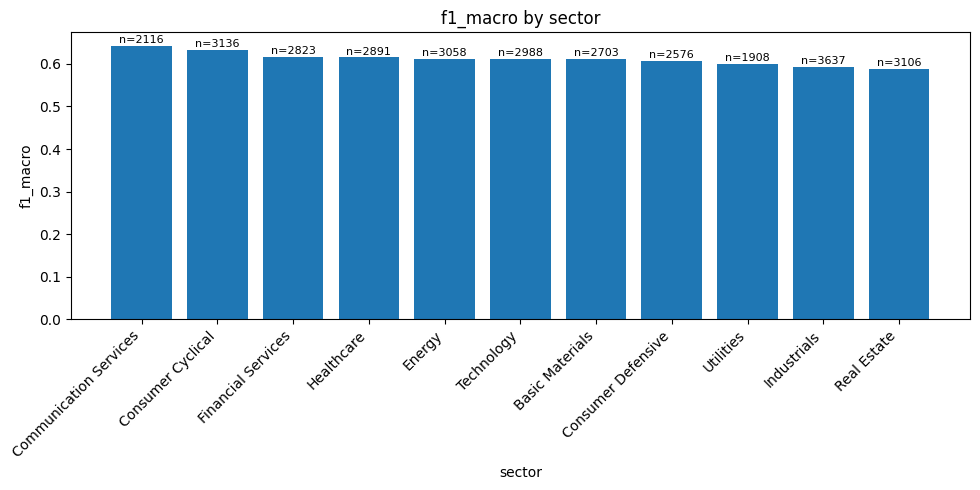

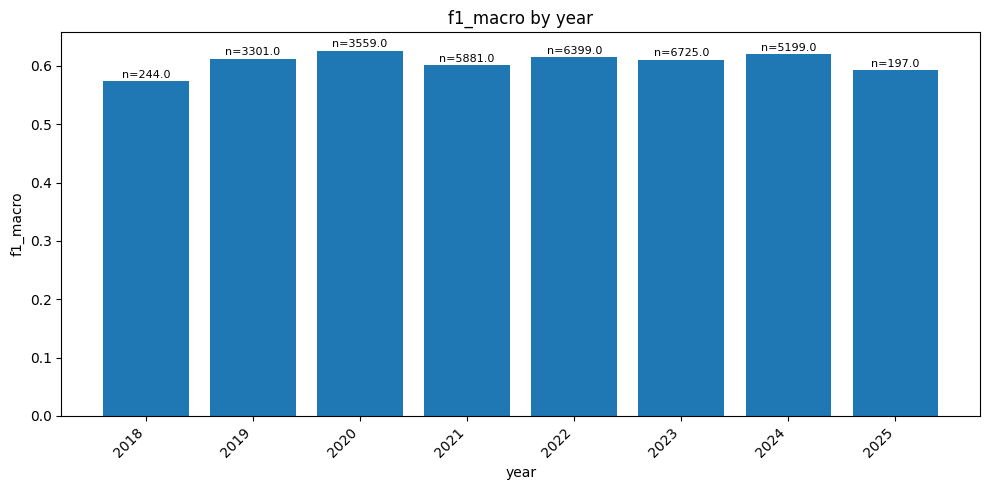

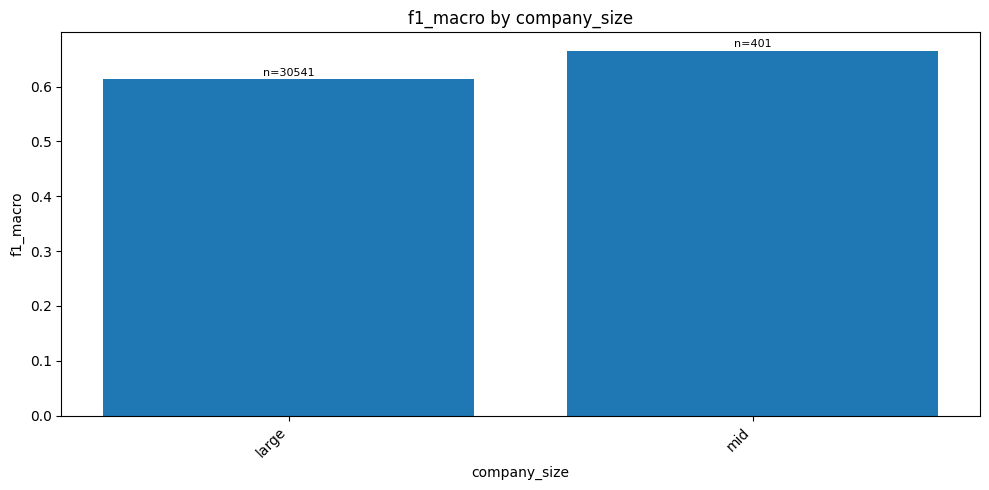

In [24]:
plot_group_bars(sector_res, "sector", metric="f1_macro")
plot_group_bars(year_res, "year", metric="f1_macro", sort_by_metric=False)
plot_group_bars(size_res, "company_size", metric="f1_macro", sort_by_metric=False)

/mnt/home/aacastro/2025_ACA_MultichannelAI/notebooks/aux.py:280: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, subdf in df.groupby(group_col):


,calls_bin,n,f1_macro,roc_auc
1,Q2_midlow,7758,0.630793,0.705843
3,Q4_high,5651,0.623021,0.685709
2,Q3_midhigh,9495,0.609406,0.687764
0,Q1_low,8601,0.595227,0.667872


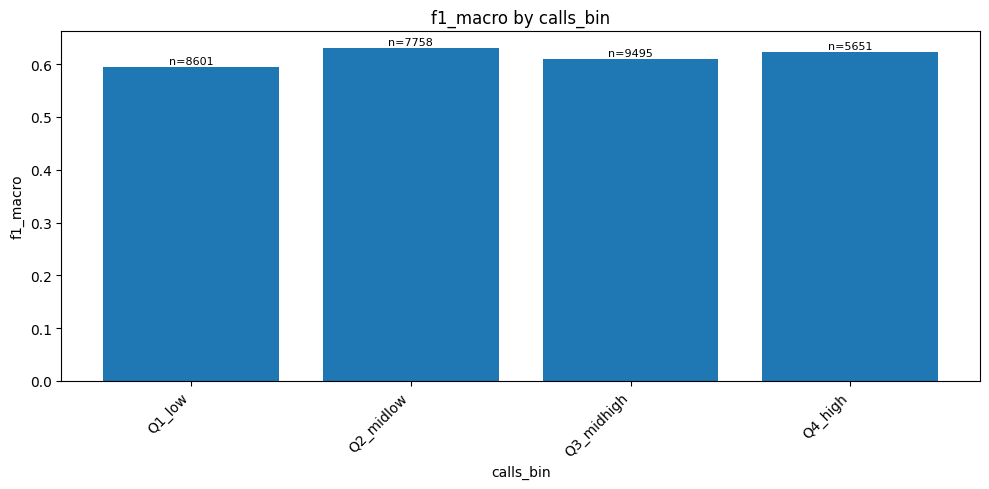

In [25]:
oof_df["calls_bin"] = pd.qcut(
    oof_df["num_calls_total"],
    q=4,
    labels=["Q1_low", "Q2_midlow", "Q3_midhigh", "Q4_high"],
    duplicates="drop"
)

calls_bin_res = evaluate_by_group(oof_df, "calls_bin")
display(calls_bin_res)
plot_group_bars(calls_bin_res, "calls_bin", metric="f1_macro", sort_by_metric=False)

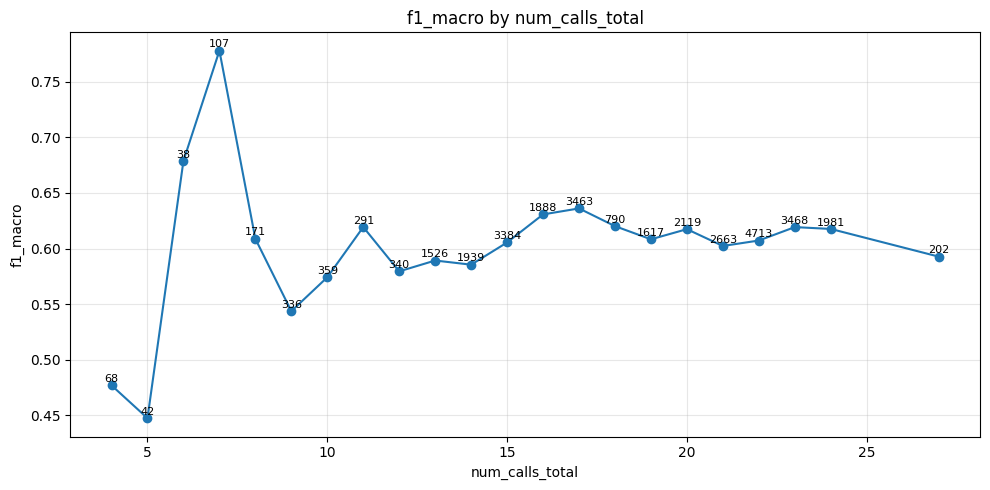

In [26]:
plot_calls_metric(calls_res, metric="f1_macro")

# Calibration

In [27]:
y_true = oof_df["y_true"].values
y_proba = oof_df["y_proba"].values

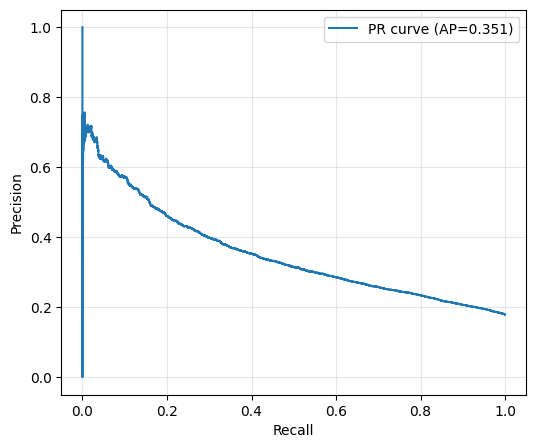

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
ap = average_precision_score(y_true, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR curve (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (OOF)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

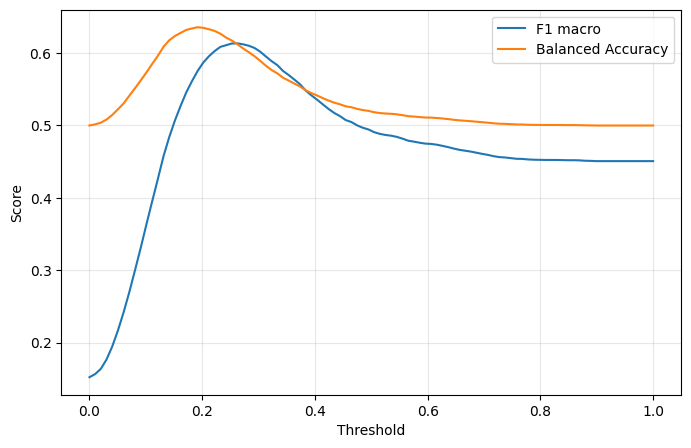

Best threshold (global OOF): 0.26262626262626265


In [ ]:
from sklearn.metrics import f1_score, balanced_accuracy_score

thresholds = np.linspace(0.0, 1.0, 100)

f1_scores = []
bal_acc_scores = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    f1_scores.append(f1)
    bal_acc_scores.append(bal_acc)

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, label="F1 macro")
plt.plot(thresholds, bal_acc_scores, label="Balanced Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metric vs Threshold (OOF)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_t = thresholds[np.argmax(f1_scores)]
print("Best threshold (global OOF):", best_t)

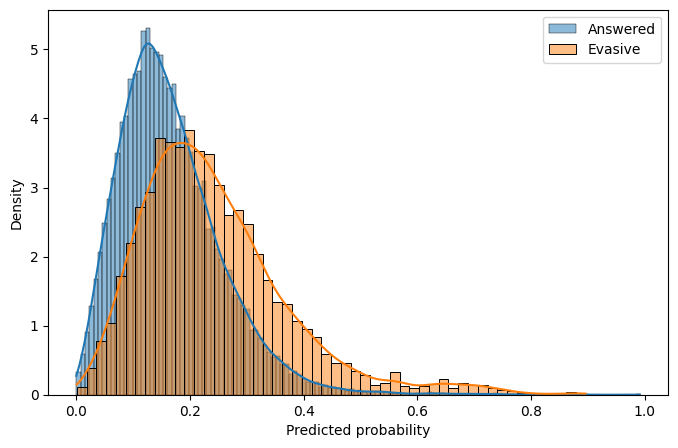

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(y_proba[y_true == 0], label="Answered", kde=True, stat="density")
sns.histplot(y_proba[y_true == 1], label="Evasive", kde=True, stat="density")

plt.xlabel("Predicted probability")
plt.title("Probability distribution by class")
plt.legend()
plt.show()

# Explainability

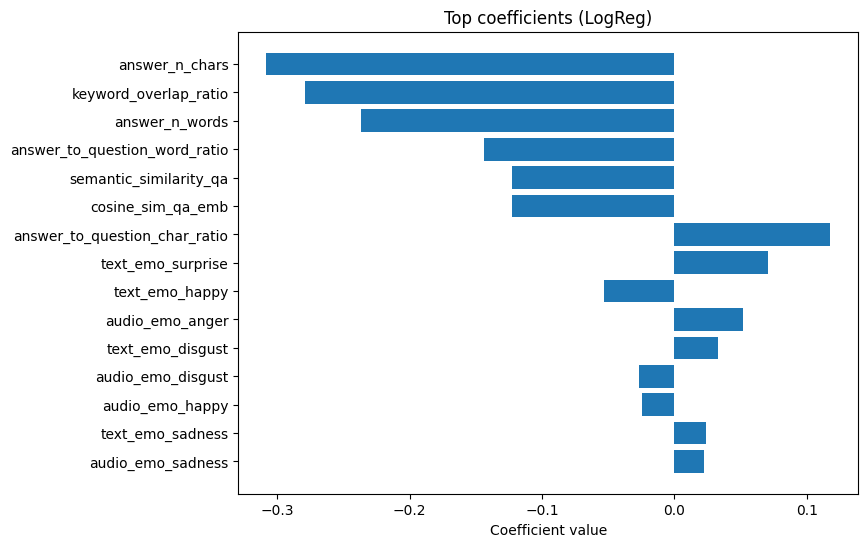

In [ ]:
log_model.fit(feature_sets_ablation["TEXT_AUDIO_STRUCT"], y_all)

coef = log_model.named_steps["model"].coef_[0]
feature_names = feature_sets_ablation["TEXT_AUDIO_STRUCT"].columns

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

top_k = 15
top_features = coef_df.head(top_k)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["coef"])
plt.gca().invert_yaxis()
plt.title("Top coefficients (LogReg)")
plt.xlabel("Coefficient value")
plt.show()

# Multiclass case

In [ ]:
X_all = pd.read_parquet("X_all_multiclass.parquet")
y_all = pd.read_parquet("y_all_multiclass.parquet").squeeze()
row_info_all = pd.read_parquet("row_info_all_multiclass.parquet")

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

X_all shape: (50063, 67)
y_all shape: (50063,)


In [ ]:
all_fold_results_ablation = []
all_summaries_ablation = []

# Baseline
dummy_fold_df, dummy_summary = evaluate_dummy_majority_cv(y=y, groups=groups, cv=gkf)
all_fold_results_ablation.append(dummy_fold_df)
all_summaries_ablation.append(dummy_summary)

for model_name, model in models.items():
    for fs_name, X in feature_sets_ablation.items():
        fold_df, summary = evaluate_model_cv(
            model=model,
            X=X,
            y=y,
            groups=groups,
            cv=gkf,
            model_name=model_name,
            feature_set_name=fs_name
        )
        all_fold_results_ablation.append(fold_df)
        all_summaries_ablation.append(summary)

fold_results_df_ablation = pd.concat(all_fold_results_ablation, ignore_index=True)

summary_df_ablation = pd.DataFrame(all_summaries_ablation)

baseline_f1 = summary_df_ablation.loc[
    summary_df_ablation["model_name"] == "DummyMajority",
    "f1_macro_mean"
].values[0]
summary_df_ablation["f1_vs_baseline"] = summary_df_ablation["f1_macro_mean"] - baseline_f1

summary_df_ablation = summary_df_ablation.sort_values(
    by="f1_vs_baseline",
    ascending=False
).reset_index(drop=True)

In [34]:
summary_df_ablation

,model_name,feature_set,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std,f1_vs_baseline
0,LogReg,TEXT_AUDIO_STRUCT,0.613472,0.002956,0.686680,0.005501,0.162719
1,LogReg,FULL,0.612284,0.004255,0.686037,0.006056,0.161531
2,LogReg,TEXT_AUDIO_STRUCT_SEMANTIC,0.612170,0.004122,0.686040,0.006057,0.161417
3,XGB,TEXT_AUDIO_STRUCT_SEMANTIC,0.610782,0.008233,0.680997,0.006064,0.160030
4,XGB,TEXT_AUDIO_STRUCT,0.610777,0.006207,0.682525,0.004106,0.160024
5,XGB,FULL,0.609823,0.005239,0.678144,0.009083,0.159070
6,RandomForest,TEXT_AUDIO_STRUCT_SEMANTIC,0.602310,0.013917,0.675992,0.008685,0.151557
7,RandomForest,FULL,0.600703,0.014531,0.673138,0.009136,0.149950
8,SVM,FULL,0.589065,0.008231,0.625069,0.009544,0.138312
9,SVM,TEXT_AUDIO_STRUCT_SEMANTIC,0.588948,0.007202,0.623271,0.008383,0.138195


# Market reaction

In [35]:
best_model_name = "LogReg"
best_feature_set_name = "TEXT_AUDIO_STRUCT"

X_best = feature_sets_ablation[best_feature_set_name]
y_best = y_all.copy()

final_model = clone(log_model)
final_model.fit(X_best, y_best)

ValueError: Found input variables with inconsistent numbers of samples: [31505, 50063]

In [ ]:
qa_pred_df = row_info_all.copy()
# decision_threshold = best_t  
decision_threshold = 0.26262626262626265

qa_pred_df["evasion_proba"] = final_model.predict_proba(X_best)[:, 1]
qa_pred_df["predicted_evasive"] = (
    qa_pred_df["evasion_proba"] >= decision_threshold
).astype(int)

qa_pred_df["model_name"] = best_model_name
qa_pred_df["feature_set"] = best_feature_set_name
qa_pred_df["decision_threshold"] = decision_threshold

# display(qa_pred_df.head())

call_evasion_df = (
    qa_pred_df
    .groupby(["company", "year", "conference"], as_index=False)
    .agg(
        n_qa_pairs=("pair_id", "count"),
        evasion_score_mean=("evasion_proba", "mean"),
        evasion_score_median=("evasion_proba", "median"),
        evasion_score_p75=("evasion_proba", lambda x: np.percentile(x, 75)),
        evasion_score_max=("evasion_proba", "max"),
        predicted_evasive_rate=("predicted_evasive", "mean"),
    )
)

# display(call_evasion_df.head())

qa_pred_df["true_evasive"] = (qa_pred_df["answered"] == "no").astype(int)

call_true_evasion_df = (
    qa_pred_df
    .groupby(["company", "year", "conference"], as_index=False)
    .agg(
        true_evasive_rate=("true_evasive", "mean")
    )
)

call_evasion_df = call_evasion_df.merge(
    call_true_evasion_df,
    on=["company", "year", "conference"],
    how="left"
)

# display(call_evasion_df.head())

call_evasion_market_df = call_evasion_df.rename(columns={
    "company": "ticker",
    "conference": "quarter"
})

display(call_evasion_market_df.head())

event_financial_df = pd.read_csv('event_financial_df.csv')

event_financial_df = event_financial_df.copy()
call_evasion_market_df = call_evasion_market_df.copy()

# Normalizar claves
event_financial_df["ticker"] = event_financial_df["ticker"].astype(str).str.strip()
call_evasion_market_df["ticker"] = call_evasion_market_df["ticker"].astype(str).str.strip()

event_financial_df["quarter"] = event_financial_df["quarter"].astype(str).str.strip()
call_evasion_market_df["quarter"] = call_evasion_market_df["quarter"].astype(str).str.strip()

event_financial_df["year"] = event_financial_df["year"].astype(int)
call_evasion_market_df["year"] = call_evasion_market_df["year"].astype(int)

# Merge
event_market_evasion_df = event_financial_df.merge(
    call_evasion_market_df,
    on=["ticker", "year", "quarter"],
    how="inner"
)

display(event_market_evasion_df.head())
print(event_market_evasion_df.shape)

df = event_market_evasion_df.copy()

# Quitar columnas basura si existen
df = df.drop(columns=[c for c in ["Unnamed: 0"] if c in df.columns])

# Filtrar eventos válidos
if "has_event_result" in df.columns:
    df = df[df["has_event_result"] == True].copy()

# Variables principales
vars_needed = [
    "evasion_score_mean",
    "predicted_evasive_rate",
    "true_evasive_rate",
    "CAR_m7_p7",
    "abs_CAR_m7_p7",
    "AR_vol_m7_p7",
    "n_qa_pairs"
]

df_plot = df.dropna(subset=[c for c in vars_needed if c in df.columns]).copy()

print("N eventos disponibles:", len(df_plot))
display(df_plot[vars_needed].describe())

,ticker,year,quarter,n_qa_pairs,evasion_score_mean,evasion_score_median,evasion_score_p75,evasion_score_max,predicted_evasive_rate,true_evasive_rate
0,AAPL,2018,Q3,5,0.155031,0.181696,0.228662,0.245192,0.000000,0.200000
1,AAPL,2018,Q4,5,0.136563,0.098802,0.176797,0.313769,0.200000,0.400000
2,AAPL,2019,Q1,5,0.099374,0.120102,0.132871,0.151879,0.000000,0.000000
3,AAPL,2019,Q2,4,0.207458,0.225703,0.241769,0.251017,0.000000,0.250000
4,AAPL,2019,Q3,6,0.221751,0.199132,0.241126,0.388912,0.166667,0.333333


,Unnamed: 0,ticker,company_name,year,quarter,event_date,estimation_start,estimation_end,gap,has_event_result,...,abs_CAR_p0_p7,AR_vol_p0_p7,mean_AR_p0_p7,n_qa_pairs,evasion_score_mean,evasion_score_median,evasion_score_p75,evasion_score_max,predicted_evasive_rate,true_evasive_rate
0,0,KMI,"Kinder Morgan, Inc.",2020,Q3,2020-10-21,2020-03-18,2020-09-14,30,True,...,0.011296,0.020549,-0.001883,9,0.209762,0.216886,0.270213,0.321878,0.444444,0.000000
1,1,KMI,"Kinder Morgan, Inc.",2020,Q4,2021-01-20,2020-10-14,2020-12-14,30,True,...,0.069531,0.014258,-0.011589,9,0.160739,0.150543,0.222062,0.328272,0.111111,0.000000
2,2,KMI,"Kinder Morgan, Inc.",2021,Q1,2021-04-21,2021-01-13,2021-03-15,30,True,...,0.040847,0.016739,0.006808,6,0.217554,0.234409,0.258684,0.380324,0.333333,0.000000
3,3,KMI,"Kinder Morgan, Inc.",2021,Q2,2021-07-21,2021-04-14,2021-06-14,30,True,...,0.004248,0.017884,-0.000708,12,0.206668,0.202120,0.263292,0.367757,0.250000,0.083333
4,4,KMI,"Kinder Morgan, Inc.",2021,Q3,2021-10-20,2021-07-14,2021-09-13,30,True,...,0.051287,0.029661,-0.008548,7,0.199845,0.191811,0.226627,0.334031,0.142857,0.285714


(3582, 28)
N eventos disponibles: 3549


KeyError: "['CAR_m7_p7', 'abs_CAR_m7_p7', 'AR_vol_m7_p7'] not in index"

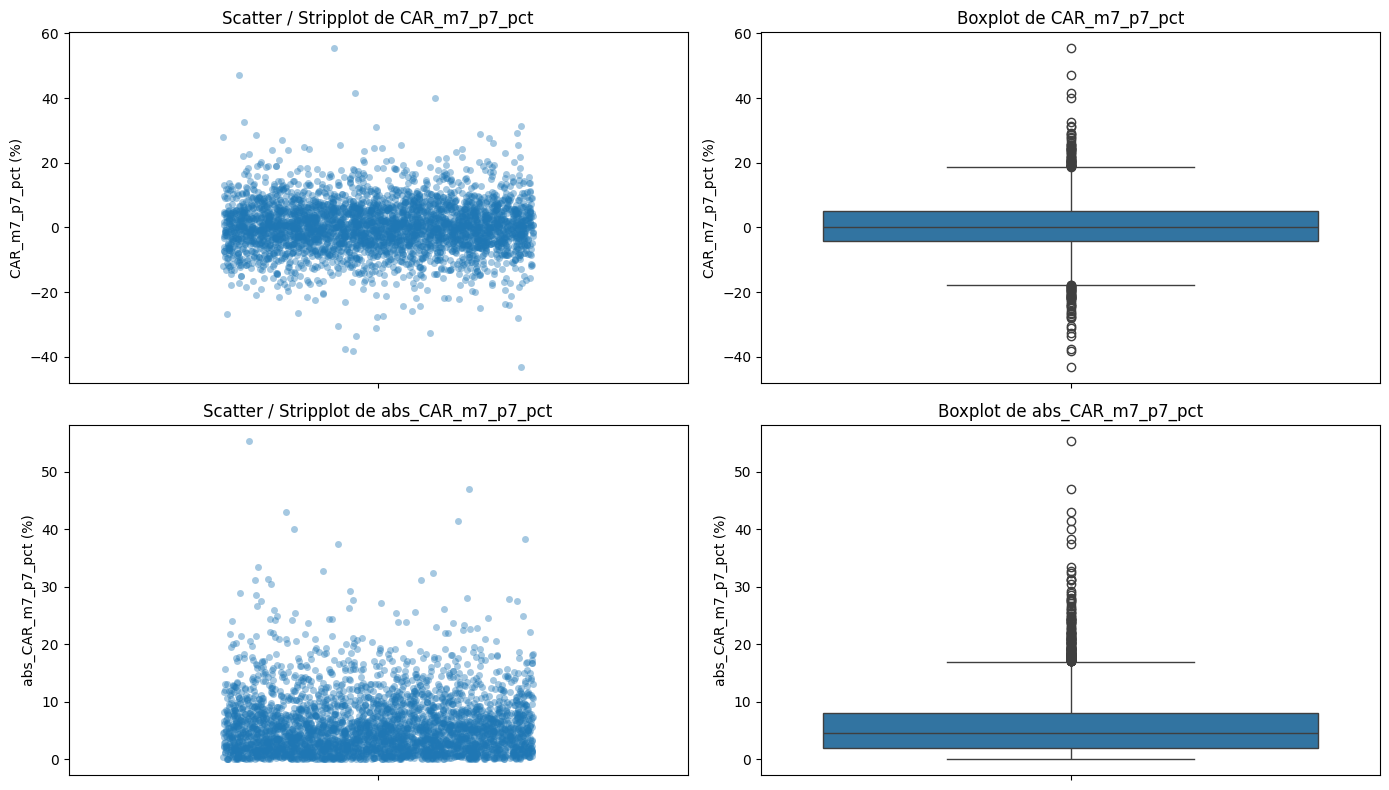

In [ ]:
df_plot_pct = df_plot.copy()

df_plot_pct["CAR_m7_p7_pct"] = df_plot_pct["CAR_m7_p7"] * 100
df_plot_pct["abs_CAR_m7_p7_pct"] = df_plot_pct["abs_CAR_m7_p7"] * 100

cols_pct = ["CAR_m7_p7_pct", "abs_CAR_m7_p7_pct"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(cols_pct):
    sns.stripplot(
        y=df_plot_pct[col],
        ax=axes[i, 0],
        jitter=0.25,
        alpha=0.4
    )
    axes[i, 0].set_title(f"Scatter / Stripplot de {col}")
    axes[i, 0].set_ylabel(f"{col} (%)")

    sns.boxplot(
        y=df_plot_pct[col],
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Boxplot de {col}")
    axes[i, 1].set_ylabel(f"{col} (%)")

plt.tight_layout()
plt.show()

In [ ]:
def get_iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    return lower, upper, outliers

for col in ["CAR_m7_p7", "abs_CAR_m7_p7"]:
    lower, upper, outliers = get_iqr_outliers(df_plot, col)
    
    print(f"\n{col}")
    print(f"Lower bound: {lower:.4f} ({lower*100:.2f}%)")
    print(f"Upper bound: {upper:.4f} ({upper*100:.2f}%)")
    print(f"N outliers: {len(outliers)}")
    print(f"% outliers: {len(outliers) / len(df_plot) * 100:.2f}%")


CAR_m7_p7
Lower bound: -0.1773 (-17.73%)
Upper bound: 0.1865 (18.65%)
N outliers: 100
% outliers: 2.82%

abs_CAR_m7_p7
Lower bound: -0.0697 (-6.97%)
Upper bound: 0.1699 (16.99%)
N outliers: 144
% outliers: 4.06%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Copia de trabajo
df_reg = df_plot.copy()

# Asegurar formato fecha
df_reg["event_date"] = pd.to_datetime(df_reg["event_date"], errors="coerce")

# Crear variable year-quarter para efectos fijos temporales
df_reg["year_quarter"] = (
    df_reg["year"].astype(str) + "Q" + df_reg["quarter"].astype(str)
)

# Variables principales
evasion_var = "evasion_score_mean"

market_outcomes = [
    "CAR_p0_p3",
    "CAR_p0_p7",
    "abs_CAR_p0_p3",
    "abs_CAR_p0_p7",
    "AR_vol_p0_p3",
    "AR_vol_p0_p7",
]

controls = [
    "n_qa_pairs"
]

needed_cols = (
    ["ticker", "company_name", "year", "quarter", "year_quarter", "event_date", evasion_var]
    + market_outcomes
    + controls
)

df_reg = df_reg[needed_cols].dropna().copy()

print("Número de observaciones:", len(df_reg))
print("Número de empresas:", df_reg["ticker"].nunique())
print("Años:", df_reg["year"].min(), "-", df_reg["year"].max())

df_reg.head()

Número de observaciones: 3516
Número de empresas: 212
Años: 2018 - 2025


,ticker,company_name,year,quarter,year_quarter,event_date,evasion_score_mean,CAR_p0_p3,CAR_p0_p7,abs_CAR_p0_p3,abs_CAR_p0_p7,AR_vol_p0_p3,AR_vol_p0_p7,n_qa_pairs
0,KMI,"Kinder Morgan, Inc.",2020,Q3,2020QQ3,2020-10-21,0.209762,0.024800,-0.011296,0.024800,0.011296,0.026730,0.020549,9
1,KMI,"Kinder Morgan, Inc.",2020,Q4,2020QQ4,2021-01-20,0.160739,-0.024347,-0.069531,0.024347,0.069531,0.015214,0.014258,9
2,KMI,"Kinder Morgan, Inc.",2021,Q1,2021QQ1,2021-04-21,0.217554,0.005964,0.040847,0.005964,0.040847,0.022370,0.016739,6
3,KMI,"Kinder Morgan, Inc.",2021,Q2,2021QQ2,2021-07-21,0.206668,-0.016107,-0.004248,0.016107,0.004248,0.021753,0.017884,12
4,KMI,"Kinder Morgan, Inc.",2021,Q3,2021QQ3,2021-10-20,0.199845,-0.034082,-0.051287,0.034082,0.051287,0.043252,0.029661,7


In [ ]:
desc_cols = [
    evasion_var,
    "n_qa_pairs",
    "CAR_p0_p3",
    "CAR_p0_p7",
    "abs_CAR_p0_p3",
    "abs_CAR_p0_p7",
    "AR_vol_p0_p3",
    "AR_vol_p0_p7",
]

desc = df_reg[desc_cols].describe().T

# Añadir versión en porcentaje para variables de mercado
desc_pct = desc.copy()

for col in [
    "CAR_p0_p3",
    "CAR_p0_p7",
    "abs_CAR_p0_p3",
    "abs_CAR_p0_p7",
    "AR_vol_p0_p3",
    "AR_vol_p0_p7",
]:
    desc_pct.loc[col, ["mean", "std", "min", "25%", "50%", "75%", "max"]] *= 100

desc_pct

,count,mean,std,min,25%,50%,75%,max
evasion_score_mean,3516.0,0.172265,0.054104,1.482792e-02,0.135604,0.168445,0.205026,0.493244
n_qa_pairs,3516.0,8.750284,4.062553,1.000000e+00,6.000000,8.000000,11.000000,39.000000
CAR_p0_p3,3516.0,0.105397,5.741710,-3.569293e+01,-2.923545,0.064136,3.276015,32.243947
CAR_p0_p7,3516.0,0.301618,6.677017,-4.433679e+01,-3.421146,0.329234,4.030242,36.570338
abs_CAR_p0_p3,3516.0,4.168804,3.948984,0.000000e+00,1.410813,3.114453,5.772870,35.692930
abs_CAR_p0_p7,3516.0,4.907989,4.536337,3.252607e-17,1.680428,3.717131,6.797396,44.336786
AR_vol_p0_p3,3516.0,2.714173,2.259925,0.000000e+00,1.173300,2.172860,3.583961,23.433844
AR_vol_p0_p7,3516.0,2.308914,1.470465,3.540989e-17,1.324413,1.982275,2.870656,15.246092


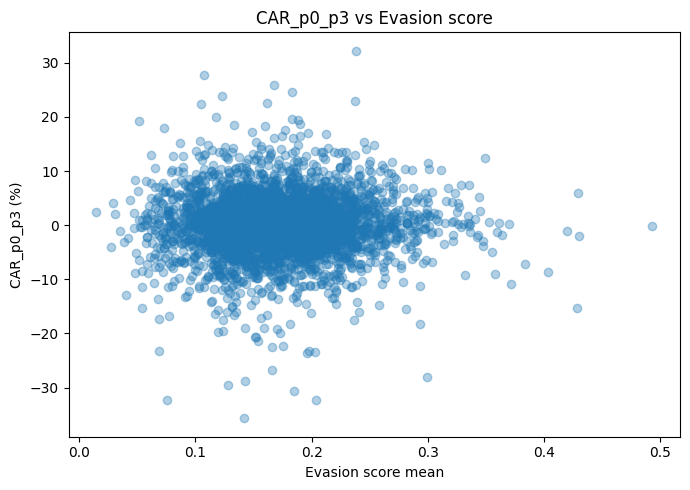

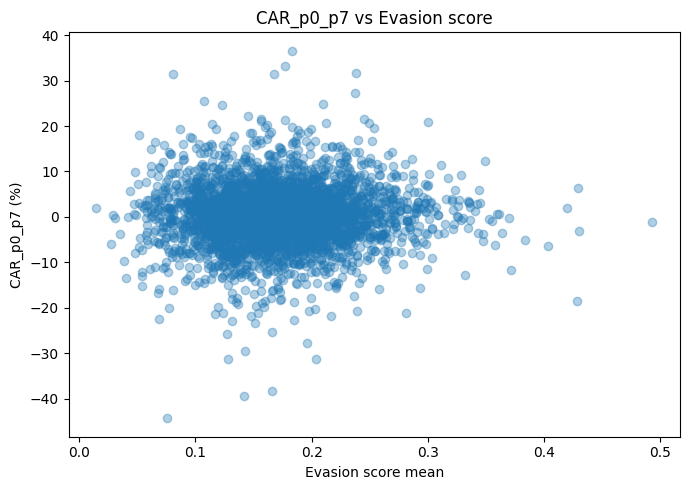

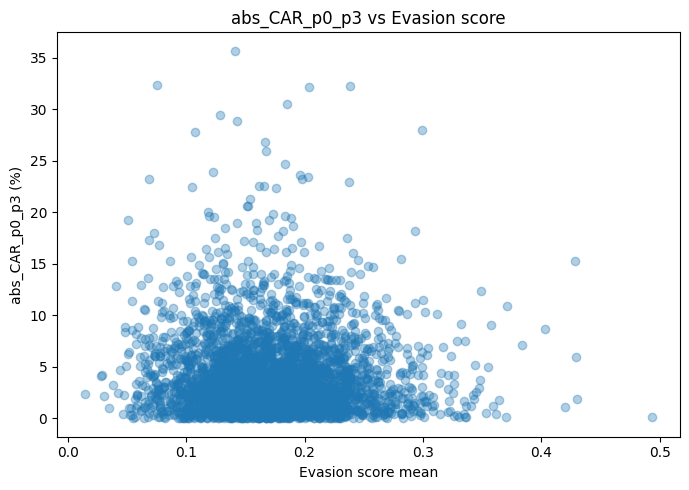

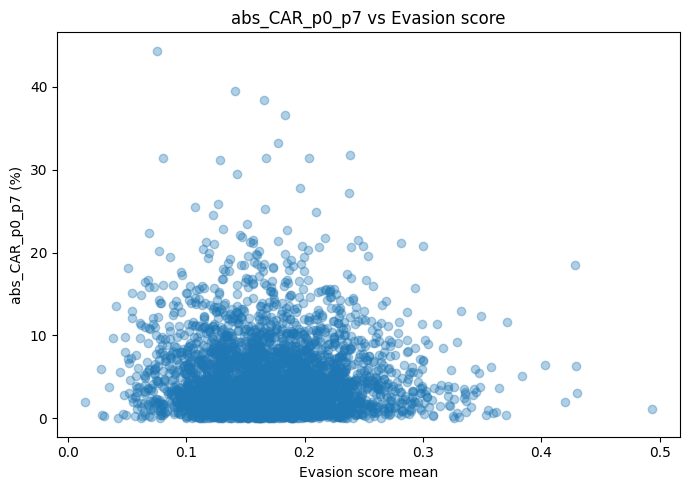

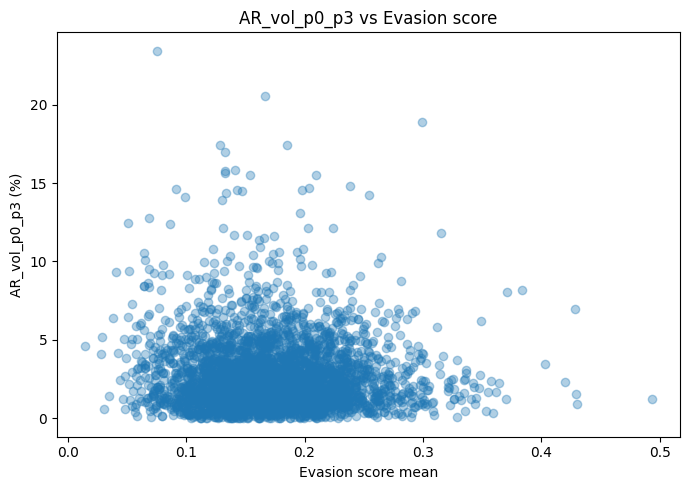

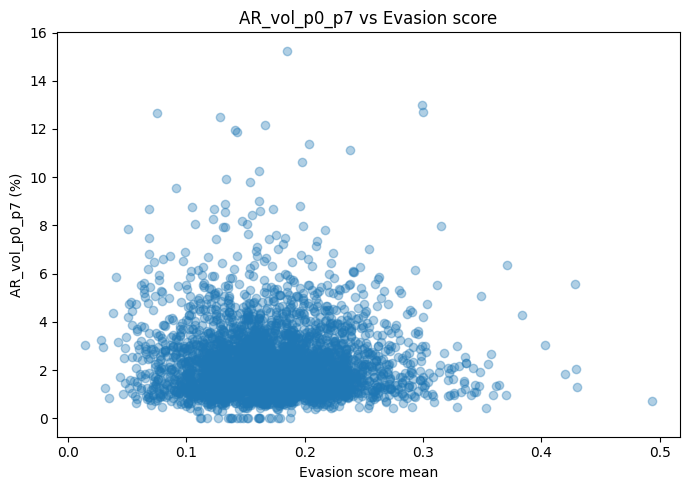

In [ ]:
for y in market_outcomes:
    plt.figure(figsize=(7, 5))
    plt.scatter(df_reg[evasion_var], df_reg[y] * 100, alpha=0.35)
    plt.xlabel("Evasion score mean")
    plt.ylabel(f"{y} (%)")
    plt.title(f"{y} vs Evasion score")
    plt.tight_layout()
    plt.show()

,CAR_p0_p3,CAR_p0_p7,abs_CAR_p0_p3,abs_CAR_p0_p7,AR_vol_p0_p3,AR_vol_p0_p7,evasion_score_mean,n_qa_pairs
evasion_quintile,,,,,,,,
Q1 lowest,0.130855,0.371271,4.499882,5.352218,2.909599,2.414157,0.101546,6.782670
Q2,-0.144464,-0.165745,4.315195,5.024767,2.785893,2.340962,0.143105,8.285917
Q3,0.053395,0.288596,3.858594,4.586728,2.576782,2.196598,0.169024,9.120910
Q4,0.184948,0.431561,4.123047,4.794895,2.614682,2.295358,0.197081,9.660028
Q5 highest,0.302216,0.582309,4.046830,4.780703,2.683632,2.297344,0.250668,9.904694


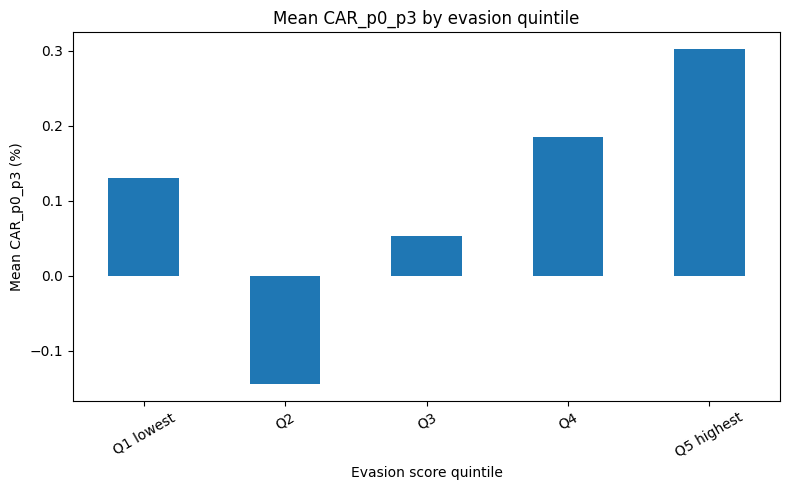

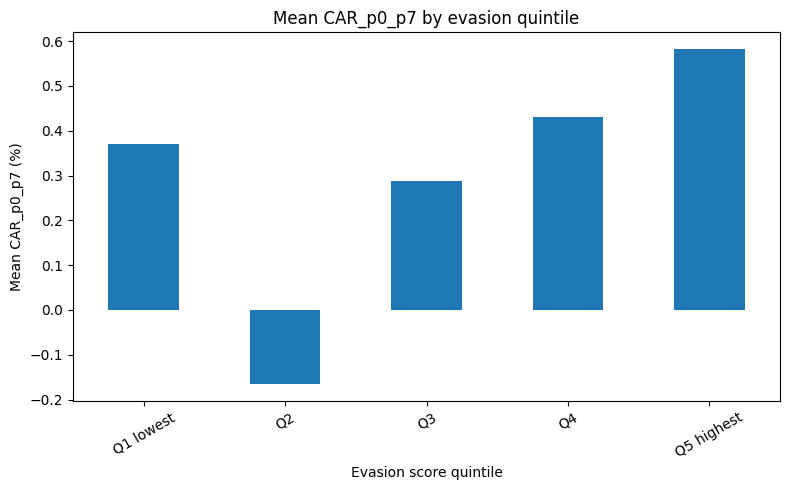

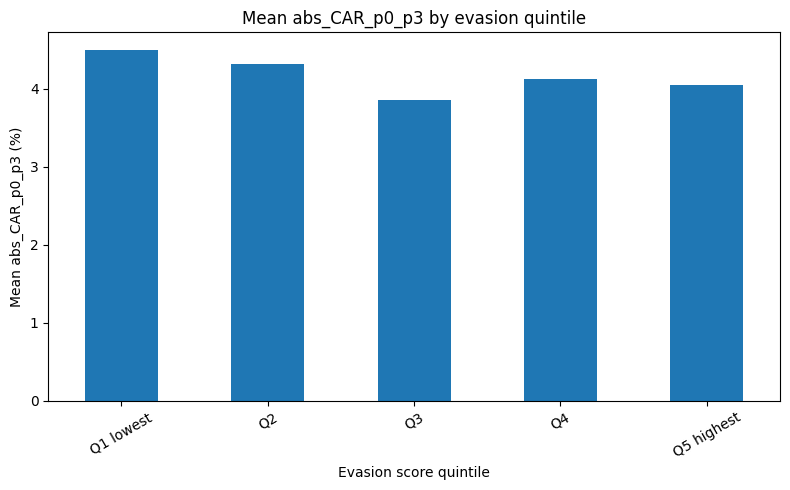

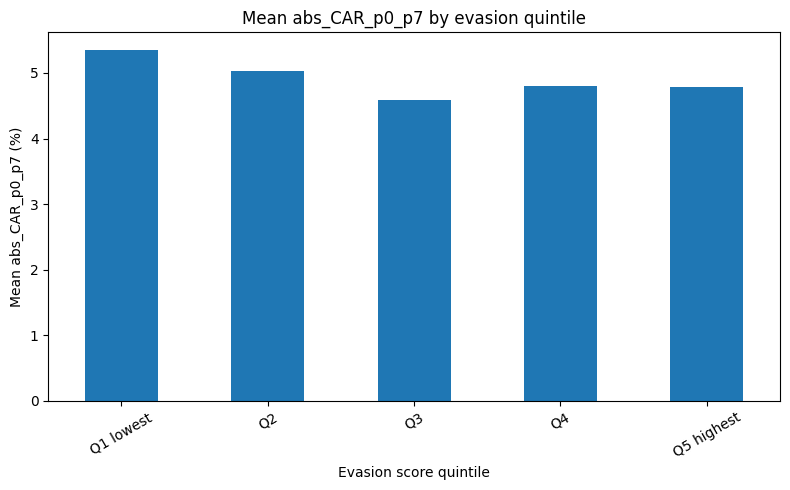

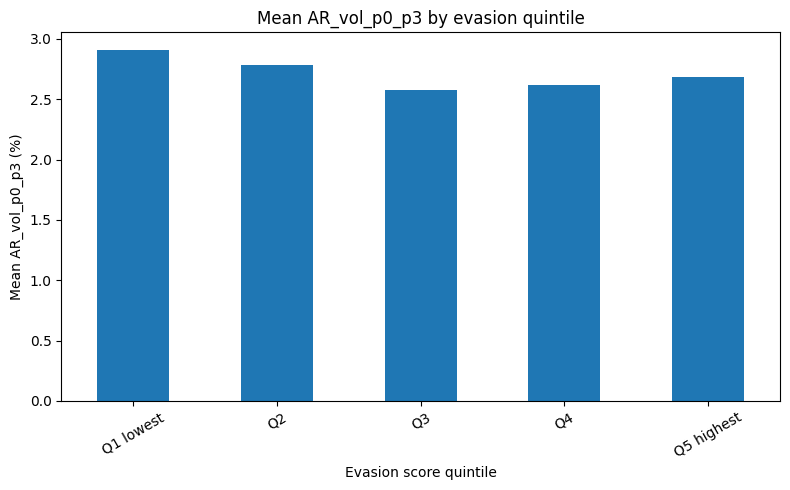

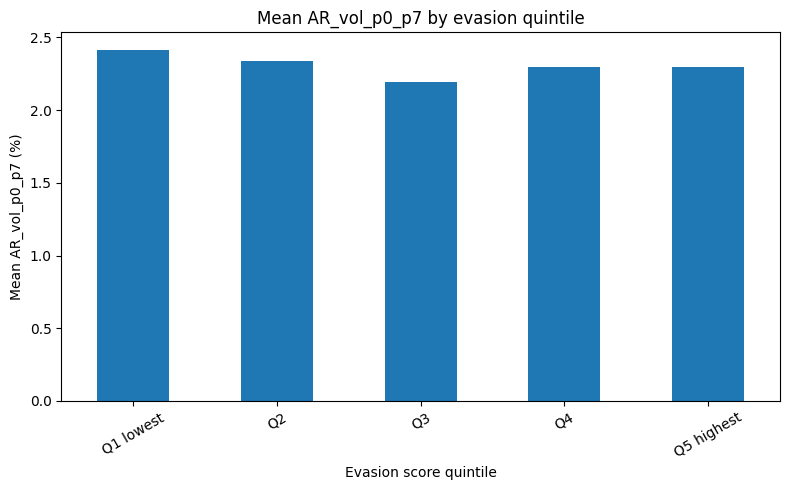

In [ ]:
df_reg["evasion_quintile"] = pd.qcut(
    df_reg[evasion_var],
    q=5,
    labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]
)

quintile_summary = (
    df_reg
    .groupby("evasion_quintile", observed=True)[market_outcomes + [evasion_var, "n_qa_pairs"]]
    .mean()
)

# Pasar outcomes de mercado a porcentaje
quintile_summary_pct = quintile_summary.copy()

for col in market_outcomes:
    quintile_summary_pct[col] *= 100

display(quintile_summary_pct)

for y in market_outcomes:
    mean_by_q = df_reg.groupby("evasion_quintile", observed=True)[y].mean() * 100
    
    plt.figure(figsize=(8, 5))
    mean_by_q.plot(kind="bar")
    plt.ylabel(f"Mean {y} (%)")
    plt.xlabel("Evasion score quintile")
    plt.title(f"Mean {y} by evasion quintile")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_market_model(df, outcome, evasion_var="evasion_score_mean"):
    """
    Regresión principal:
    outcome ~ evasion + n_qa_pairs + firm FE + year-quarter FE
    
    Errores estándar clusterizados por ticker.
    """
    
    model_df = df[
        [outcome, evasion_var, "n_qa_pairs", "ticker", "year_quarter"]
    ].dropna().copy()
    
    formula = (
        f"{outcome} ~ {evasion_var} + n_qa_pairs "
        f"+ C(ticker) + C(year_quarter)"
    )
    
    model = smf.ols(
        formula=formula,
        data=model_df
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": model_df["ticker"]}
    )
    
    return model

results = {}

for y in market_outcomes:
    print("=" * 90)
    print(f"Outcome: {y}")
    print("=" * 90)
    
    model = run_market_model(df_reg, y, evasion_var=evasion_var)
    results[y] = model
    
    print(model.summary())

Outcome: CAR_p0_p3
                            OLS Regression Results                            
Dep. Variable:              CAR_p0_p3   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                     3.547
Date:                Tue, 26 May 2026   Prob (F-statistic):           5.37e-08
Time:                        22:06:59   Log-Likelihood:                 5179.7
No. Observations:                3516   AIC:                            -9877.
Df Residuals:                    3275   BIC:                            -8392.
Df Model:                         240                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
I

/home/aacastro/env_6-1-2026/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 240, but rank is 29
  warnings.warn('covariance of constraints does not have full '
/home/aacastro/env_6-1-2026/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 240, but rank is 29
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:              CAR_p0_p7   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     3.911
Date:                Tue, 26 May 2026   Prob (F-statistic):           3.78e-09
Time:                        22:06:59   Log-Likelihood:                 4651.4
No. Observations:                3516   AIC:                            -8821.
Df Residuals:                    3275   BIC:                            -7335.
Df Model:                         240                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/home/aacastro/env_6-1-2026/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 240, but rank is 29
  warnings.warn('covariance of constraints does not have full '
/home/aacastro/env_6-1-2026/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 240, but rank is 29
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:          abs_CAR_p0_p7   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     8.789
Date:                Tue, 26 May 2026   Prob (F-statistic):           3.60e-23
Time:                        22:06:59   Log-Likelihood:                 6323.1
No. Observations:                3516   AIC:                        -1.216e+04
Df Residuals:                    3275   BIC:                        -1.068e+04
Df Model:                         240                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/home/aacastro/env_6-1-2026/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 240, but rank is 29
  warnings.warn('covariance of constraints does not have full '
/home/aacastro/env_6-1-2026/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 240, but rank is 29
  warnings.warn('covariance of constraints does not have full '


In [ ]:
import pandas as pd
import numpy as np

df_reg = event_market_evasion_df.copy()

df_reg = df_reg.drop(columns=[c for c in ["Unnamed: 0"] if c in df_reg.columns])

if "has_event_result" in df_reg.columns:
    df_reg = df_reg[df_reg["has_event_result"] == True].copy()

df_reg["ticker"] = df_reg["ticker"].astype(str)
df_reg["year"] = df_reg["year"].astype(int)
df_reg["quarter"] = df_reg["quarter"].astype(str)

# Variable de fixed effect temporal más específica que solo quarter
df_reg["year_quarter"] = df_reg["year"].astype(str) + "_" + df_reg["quarter"].astype(str)

needed_cols = [
    "ticker",
    "year_quarter",
    "n_qa_pairs",
    "true_evasive_rate",
    "predicted_evasive_rate",
    "evasion_score_mean",
    "CAR_p0_p3",
    "CAR_p0_p7",
    "abs_CAR_p0_p3",
    "abs_CAR_p0_p7",
]

df_reg = df_reg.dropna(subset=[c for c in needed_cols if c in df_reg.columns]).copy()

print(df_reg.shape)
display(df_reg[needed_cols].describe(include="all"))

def run_market_regression(df, dep_var, evasion_var):
    """
    Regression:
    dep_var ~ evasion_var + n_qa_pairs + firm FE + quarter FE
    clustered SE at ticker level.
    """

    formula = f"{dep_var} ~ {evasion_var} + n_qa_pairs + C(ticker) + C(year_quarter)"

    model = smf.ols(formula=formula, data=df)

    res = model.fit(
        cov_type="cluster",
        cov_kwds={"groups": df["ticker"]}
    )

    return res

dep_vars = [
    ("CAR_p0_p3", r"CAR$_{[0,+3]}$"),
    ("CAR_p0_p7", r"CAR$_{[0,+7]}$"),
    ("abs_CAR_p0_p3", r"$|$CAR$|_{[0,+3]}$"),
    ("abs_CAR_p0_p7", r"$|$CAR$|_{[0,+7]}$"),
    ("AR_vol_p0_p3", r"AR\_vol$_{[0,+3]}$"),
    ("AR_vol_p0_p7", r"AR\_vol$_{[0,+7]}$"),
]

evasion_vars = [
    "true_evasive_rate",
    "predicted_evasive_rate",
    "evasion_score_mean",
]

rows = []

for dep_var, dep_label in dep_vars:
    for evasion_var in evasion_vars:
        sub = df_reg.dropna(subset=[dep_var, evasion_var, "n_qa_pairs", "ticker", "year_quarter"]).copy()

        res = run_market_regression(
            df=sub,
            dep_var=dep_var,
            evasion_var=evasion_var
        )

        rows.append({
            "Dependent variable": dep_label,
            "Evasion measure": evasion_var,
            "Coefficient": res.params.get(evasion_var, np.nan),
            "Std. Error": res.bse.get(evasion_var, np.nan),
            "p-value": res.pvalues.get(evasion_var, np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })

market_regression_table = pd.DataFrame(rows)

display(market_regression_table)

(3549, 28)


,ticker,year_quarter,n_qa_pairs,true_evasive_rate,predicted_evasive_rate,evasion_score_mean,CAR_p0_p3,CAR_p0_p7,abs_CAR_p0_p3,abs_CAR_p0_p7
count,3549,3549,3549.000000,3549.000000,3549.000000,3549.000000,3549.000000,3549.000000,3549.000000,3.549000e+03
unique,212,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,AMAT,2023_Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,24,191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,8.751479,0.174633,0.157558,0.172341,0.001011,0.002806,0.041531,4.903692e-02
std,NaN,NaN,4.068495,0.156162,0.168623,0.054139,0.057236,0.066675,0.039392,4.525672e-02
min,NaN,NaN,1.000000,0.000000,0.000000,0.014828,-0.356929,-0.443368,0.000000,3.252607e-19
25%,NaN,NaN,6.000000,0.000000,0.000000,0.135608,-0.029188,-0.034373,0.014017,1.690726e-02
50%,NaN,NaN,8.000000,0.153846,0.125000,0.168626,0.000658,0.002918,0.030993,3.716779e-02
75%,NaN,NaN,11.000000,0.272727,0.250000,0.205310,0.032451,0.040185,0.057363,6.792699e-02


,Dependent variable,Evasion measure,Coefficient,Std. Error,p-value,N,R2
0,"CAR$_{[0,+3]}$",true_evasive_rate,-0.005547,0.007379,0.452199,3549,0.066682
1,"CAR$_{[0,+3]}$",predicted_evasive_rate,0.007414,0.006242,0.234906,3549,0.066804
2,"CAR$_{[0,+3]}$",evasion_score_mean,0.003463,0.023237,0.881529,3549,0.066501
3,"CAR$_{[0,+7]}$",true_evasive_rate,-0.000951,0.008732,0.913294,3549,0.067208
4,"CAR$_{[0,+7]}$",predicted_evasive_rate,0.009029,0.007039,0.199574,3549,0.067540
5,"CAR$_{[0,+7]}$",evasion_score_mean,0.008802,0.026442,0.739223,3549,0.067228
6,"$|$CAR$|_{[0,+3]}$",true_evasive_rate,0.009035,0.004796,0.059601,3549,0.234813
7,"$|$CAR$|_{[0,+3]}$",predicted_evasive_rate,0.001742,0.004545,0.701520,3549,0.233810
8,"$|$CAR$|_{[0,+3]}$",evasion_score_mean,0.002624,0.016281,0.871939,3549,0.233781
9,"$|$CAR$|_{[0,+7]}$",true_evasive_rate,0.010158,0.005361,0.058140,3549,0.220225


In [ ]:
summary_rows = []

sd_evasion = df_reg[evasion_var].std()

for y, model in results.items():
    beta = model.params.get(evasion_var)
    se = model.bse.get(evasion_var)
    pval = model.pvalues.get(evasion_var)
    
    # Efecto de una desviación estándar de evasión sobre el outcome
    effect_1sd = beta * sd_evasion
    
    summary_rows.append({
        "outcome": y,
        "coef_evasion": beta,
        "se_clustered": se,
        "p_value": pval,
        "effect_1sd_decimal": effect_1sd,
        "effect_1sd_percentage_points": effect_1sd * 100,
        "nobs": int(model.nobs),
        "r2": model.rsquared
    })

summary_table = pd.DataFrame(summary_rows)

summary_table_pretty = summary_table.copy()

summary_table_pretty["coef_evasion_pct_points"] = (
    summary_table_pretty["coef_evasion"] * 100
)

summary_table_pretty["se_clustered_pct_points"] = (
    summary_table_pretty["se_clustered"] * 100
)

summary_table_pretty = summary_table_pretty[
    [
        "outcome",
        "coef_evasion_pct_points",
        "se_clustered_pct_points",
        "p_value",
        "effect_1sd_percentage_points",
        "nobs",
        "r2"
    ]
]

summary_table_pretty

,outcome,coef_evasion_pct_points,se_clustered_pct_points,p_value,effect_1sd_percentage_points,nobs,r2
0,CAR_p0_p3,0.330974,2.338543,0.887451,0.017919,3516,0.066789
1,CAR_p0_p7,0.905204,2.643812,0.732061,0.049007,3516,0.067994
2,abs_CAR_p0_p3,0.337110,1.637352,0.836879,0.018251,3516,0.233757
3,abs_CAR_p0_p7,0.387646,1.738693,0.823572,0.020987,3516,0.219816
4,AR_vol_p0_p3,0.815240,1.081639,0.451025,0.044137,3516,0.247063
5,AR_vol_p0_p7,0.728807,0.698118,0.296503,0.039457,3516,0.344001


In [ ]:
alt_evasion_var = "predicted_evasive_rate"

df_alt = df_plot.copy()
df_alt["event_date"] = pd.to_datetime(df_alt["event_date"], errors="coerce")
df_alt["year_quarter"] = (
    df_alt["year"].astype(str) + "Q" + df_alt["quarter"].astype(str)
)

needed_alt_cols = [
    "ticker",
    "year_quarter",
    "n_qa_pairs",
    alt_evasion_var
] + market_outcomes

df_alt = df_alt[needed_alt_cols].dropna().copy()

def run_market_model_alt(df, outcome, evasion_var):
    model_df = df[
        [outcome, evasion_var, "n_qa_pairs", "ticker", "year_quarter"]
    ].dropna().copy()
    
    formula = (
        f"{outcome} ~ {evasion_var} + n_qa_pairs "
        f"+ C(ticker) + C(year_quarter)"
    )
    
    model = smf.ols(
        formula=formula,
        data=model_df
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": model_df["ticker"]}
    )
    
    return model

alt_results = {}

for y in market_outcomes:
    alt_results[y] = run_market_model_alt(df_alt, y, alt_evasion_var)

alt_summary_rows = []

sd_alt_evasion = df_alt[alt_evasion_var].std()

for y, model in alt_results.items():
    beta = model.params.get(alt_evasion_var)
    se = model.bse.get(alt_evasion_var)
    pval = model.pvalues.get(alt_evasion_var)
    effect_1sd = beta * sd_alt_evasion
    
    alt_summary_rows.append({
        "outcome": y,
        "evasion_measure": alt_evasion_var,
        "coef_pct_points": beta * 100,
        "se_pct_points": se * 100,
        "p_value": pval,
        "effect_1sd_percentage_points": effect_1sd * 100,
        "nobs": int(model.nobs),
        "r2": model.rsquared
    })

alt_summary_table = pd.DataFrame(alt_summary_rows)

alt_summary_table

,outcome,evasion_measure,coef_pct_points,se_pct_points,p_value,effect_1sd_percentage_points,nobs,r2
0,CAR_p0_p3,predicted_evasive_rate,0.753734,0.628010,0.230064,0.127258,3516,0.067102
1,CAR_p0_p7,predicted_evasive_rate,0.937483,0.705639,0.183994,0.158281,3516,0.068331
2,abs_CAR_p0_p3,predicted_evasive_rate,0.193670,0.456099,0.671111,0.032699,3516,0.233791
3,abs_CAR_p0_p7,predicted_evasive_rate,0.337267,0.496973,0.497364,0.056943,3516,0.219908
4,AR_vol_p0_p3,predicted_evasive_rate,0.329302,0.286518,0.250423,0.055598,3516,0.247275
5,AR_vol_p0_p7,predicted_evasive_rate,0.157658,0.184040,0.391638,0.026618,3516,0.343876


In [ ]:
alt_evasion_var = "true_evasive_rate"

df_true = df_plot.copy()
df_true["event_date"] = pd.to_datetime(df_true["event_date"], errors="coerce")
df_true["year_quarter"] = (
    df_true["year"].astype(str) + "Q" + df_true["quarter"].astype(str)
)

needed_true_cols = [
    "ticker",
    "year_quarter",
    "n_qa_pairs",
    alt_evasion_var
] + market_outcomes

df_true = df_true[needed_true_cols].dropna().copy()

true_results = {}

for y in market_outcomes:
    true_results[y] = run_market_model_alt(df_true, y, alt_evasion_var)

true_summary_rows = []

sd_true_evasion = df_true[alt_evasion_var].std()

for y, model in true_results.items():
    beta = model.params.get(alt_evasion_var)
    se = model.bse.get(alt_evasion_var)
    pval = model.pvalues.get(alt_evasion_var)
    effect_1sd = beta * sd_true_evasion
    
    true_summary_rows.append({
        "outcome": y,
        "evasion_measure": alt_evasion_var,
        "coef_pct_points": beta * 100,
        "se_pct_points": se * 100,
        "p_value": pval,
        "effect_1sd_percentage_points": effect_1sd * 100,
        "nobs": int(model.nobs),
        "r2": model.rsquared
    })

true_summary_table = pd.DataFrame(true_summary_rows)

true_summary_table

,outcome,evasion_measure,coef_pct_points,se_pct_points,p_value,effect_1sd_percentage_points,nobs,r2
0,CAR_p0_p3,true_evasive_rate,-0.581243,0.743032,0.434062,-0.090792,3516,0.066987
1,CAR_p0_p7,true_evasive_rate,-0.160117,0.875787,0.854934,-0.025011,3516,0.067980
2,abs_CAR_p0_p3,true_evasive_rate,0.925172,0.483071,0.055469,0.144514,3516,0.234830
3,abs_CAR_p0_p7,true_evasive_rate,0.993285,0.542091,0.066904,0.155153,3516,0.220752
4,AR_vol_p0_p3,true_evasive_rate,0.671000,0.269418,0.012754,0.104812,3516,0.248624
5,AR_vol_p0_p7,true_evasive_rate,0.408601,0.173513,0.018529,0.063824,3516,0.345188


In [ ]:
main_compare = summary_table_pretty.copy()
main_compare["evasion_measure"] = "evasion_score_mean"

main_compare = main_compare.rename(columns={
    "coef_evasion_pct_points": "coef_pct_points",
    "se_clustered_pct_points": "se_pct_points"
})

main_compare = main_compare[
    [
        "outcome",
        "evasion_measure",
        "coef_pct_points",
        "se_pct_points",
        "p_value",
        "effect_1sd_percentage_points",
        "nobs",
        "r2"
    ]
]

comparison_table = pd.concat(
    [
        main_compare,
        alt_summary_table,
        true_summary_table
    ],
    ignore_index=True
)

comparison_table.sort_values(["outcome", "evasion_measure"])

,outcome,evasion_measure,coef_pct_points,se_pct_points,p_value,effect_1sd_percentage_points,nobs,r2
4,AR_vol_p0_p3,evasion_score_mean,0.815240,1.081639,0.451025,0.044137,3516,0.247063
10,AR_vol_p0_p3,predicted_evasive_rate,0.329302,0.286518,0.250423,0.055598,3516,0.247275
16,AR_vol_p0_p3,true_evasive_rate,0.671000,0.269418,0.012754,0.104812,3516,0.248624
5,AR_vol_p0_p7,evasion_score_mean,0.728807,0.698118,0.296503,0.039457,3516,0.344001
11,AR_vol_p0_p7,predicted_evasive_rate,0.157658,0.184040,0.391638,0.026618,3516,0.343876
17,AR_vol_p0_p7,true_evasive_rate,0.408601,0.173513,0.018529,0.063824,3516,0.345188
0,CAR_p0_p3,evasion_score_mean,0.330974,2.338543,0.887451,0.017919,3516,0.066789
6,CAR_p0_p3,predicted_evasive_rate,0.753734,0.628010,0.230064,0.127258,3516,0.067102
12,CAR_p0_p3,true_evasive_rate,-0.581243,0.743032,0.434062,-0.090792,3516,0.066987
1,CAR_p0_p7,evasion_score_mean,0.905204,2.643812,0.732061,0.049007,3516,0.067994


In [ ]:
paper_table = summary_table_pretty.copy()

paper_table["coef_se"] = (
    paper_table["coef_evasion_pct_points"].round(3).astype(str)
    + " (" +
    paper_table["se_clustered_pct_points"].round(3).astype(str)
    + ")"
)

paper_table["effect_1sd_pp"] = paper_table["effect_1sd_percentage_points"].round(3)

paper_table_final = paper_table[
    [
        "outcome",
        "coef_se",
        "p_value",
        "effect_1sd_pp",
        "nobs",
        "r2"
    ]
]

paper_table_final

,outcome,coef_se,p_value,effect_1sd_pp,nobs,r2
0,CAR_p0_p3,0.331 (2.339),0.887451,0.018,3516,0.066789
1,CAR_p0_p7,0.905 (2.644),0.732061,0.049,3516,0.067994
2,abs_CAR_p0_p3,0.337 (1.637),0.836879,0.018,3516,0.233757
3,abs_CAR_p0_p7,0.388 (1.739),0.823572,0.021,3516,0.219816
4,AR_vol_p0_p3,0.815 (1.082),0.451025,0.044,3516,0.247063
5,AR_vol_p0_p7,0.729 (0.698),0.296503,0.039,3516,0.344001


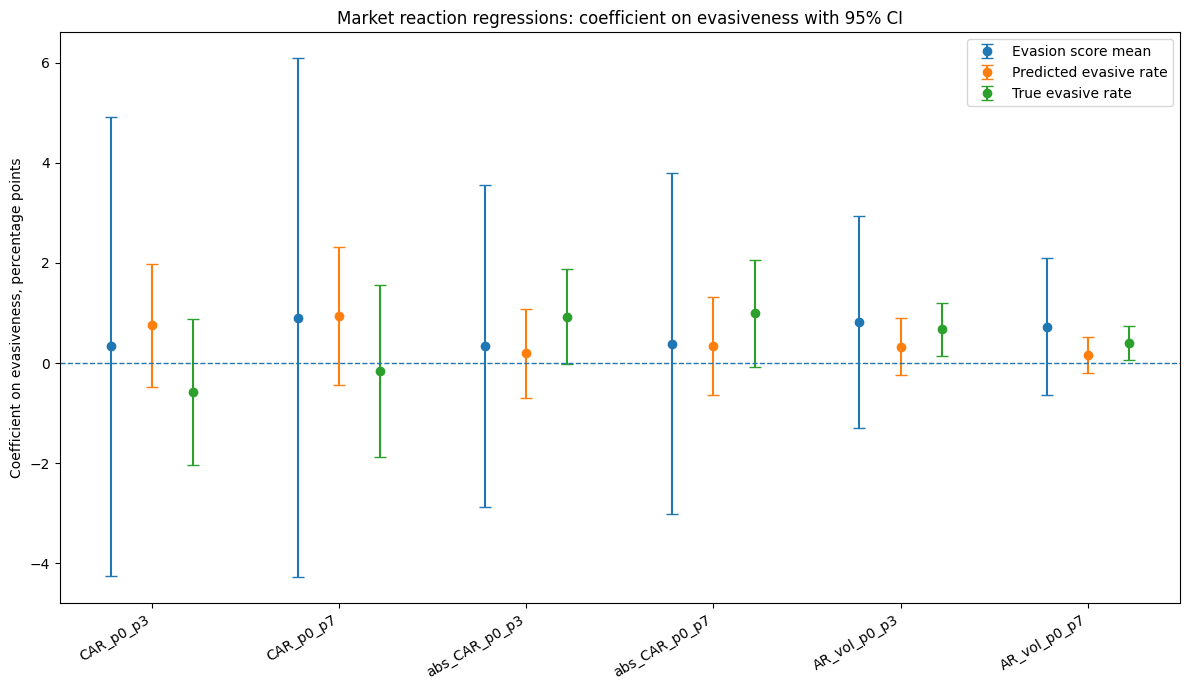

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Copia de la tabla de comparación
coef_plot = comparison_table.copy()

# Orden deseado
outcome_order = [
    "CAR_p0_p3",
    "CAR_p0_p7",
    "abs_CAR_p0_p3",
    "abs_CAR_p0_p7",
    "AR_vol_p0_p3",
    "AR_vol_p0_p7",
]

measure_order = [
    "evasion_score_mean",
    "predicted_evasive_rate",
    "true_evasive_rate",
]

coef_plot["outcome"] = pd.Categorical(
    coef_plot["outcome"],
    categories=outcome_order,
    ordered=True
)

coef_plot["evasion_measure"] = pd.Categorical(
    coef_plot["evasion_measure"],
    categories=measure_order,
    ordered=True
)

coef_plot = coef_plot.sort_values(["outcome", "evasion_measure"]).copy()

# Intervalos de confianza 95%
coef_plot["ci_low"] = coef_plot["coef_pct_points"] - 1.96 * coef_plot["se_pct_points"]
coef_plot["ci_high"] = coef_plot["coef_pct_points"] + 1.96 * coef_plot["se_pct_points"]

fig, ax = plt.subplots(figsize=(12, 7))

x_base = np.arange(len(outcome_order))
offsets = {
    "evasion_score_mean": -0.22,
    "predicted_evasive_rate": 0.00,
    "true_evasive_rate": 0.22,
}

labels = {
    "evasion_score_mean": "Evasion score mean",
    "predicted_evasive_rate": "Predicted evasive rate",
    "true_evasive_rate": "True evasive rate",
}

for measure in measure_order:
    temp = coef_plot[coef_plot["evasion_measure"] == measure].copy()
    
    x = x_base + offsets[measure]
    y = temp["coef_pct_points"].values
    yerr_lower = y - temp["ci_low"].values
    yerr_upper = temp["ci_high"].values - y
    
    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        capsize=4,
        label=labels[measure]
    )

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x_base)
ax.set_xticklabels(outcome_order, rotation=30, ha="right")

ax.set_ylabel("Coefficient on evasiveness, percentage points")
ax.set_title("Market reaction regressions: coefficient on evasiveness with 95% CI")
ax.legend()

plt.tight_layout()
plt.show()

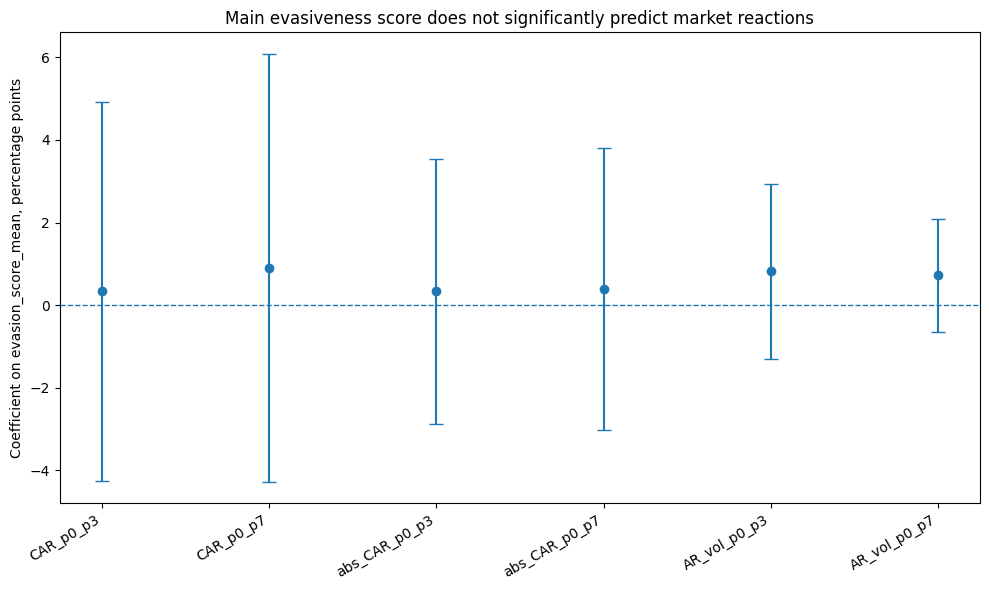

In [ ]:
main_plot = summary_table_pretty.copy()

main_plot["ci_low"] = (
    main_plot["coef_evasion_pct_points"]
    - 1.96 * main_plot["se_clustered_pct_points"]
)

main_plot["ci_high"] = (
    main_plot["coef_evasion_pct_points"]
    + 1.96 * main_plot["se_clustered_pct_points"]
)

main_plot["outcome"] = pd.Categorical(
    main_plot["outcome"],
    categories=outcome_order,
    ordered=True
)

main_plot = main_plot.sort_values("outcome").copy()

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(main_plot))
y = main_plot["coef_evasion_pct_points"].values

yerr_lower = y - main_plot["ci_low"].values
yerr_upper = main_plot["ci_high"].values - y

ax.errorbar(
    x,
    y,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    capsize=5
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(main_plot["outcome"], rotation=30, ha="right")

ax.set_ylabel("Coefficient on evasion_score_mean, percentage points")
ax.set_title("Main evasiveness score does not significantly predict market reactions")

plt.tight_layout()
plt.show()

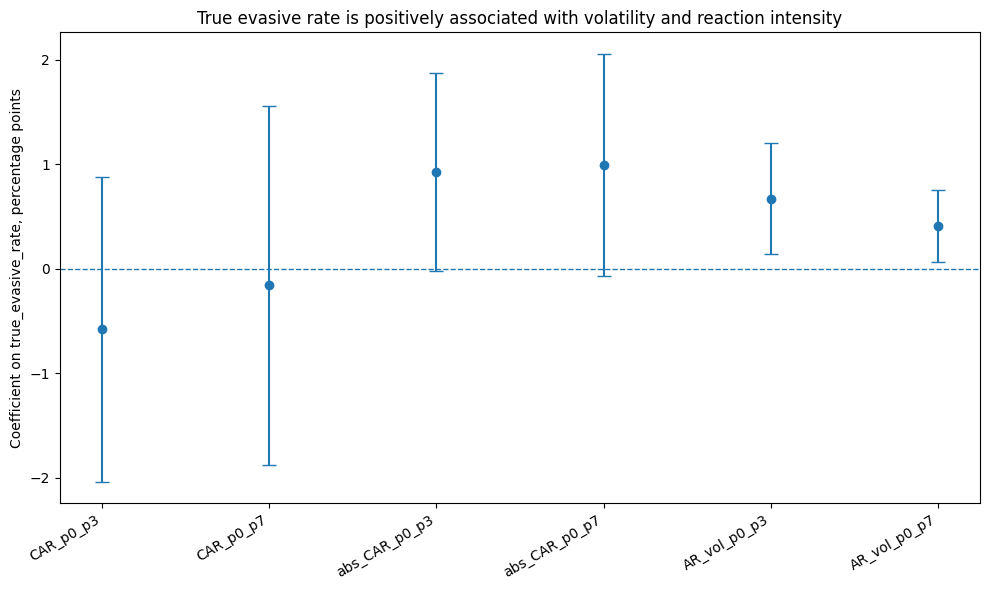

In [ ]:
true_plot = comparison_table[
    comparison_table["evasion_measure"] == "true_evasive_rate"
].copy()

true_plot["ci_low"] = true_plot["coef_pct_points"] - 1.96 * true_plot["se_pct_points"]
true_plot["ci_high"] = true_plot["coef_pct_points"] + 1.96 * true_plot["se_pct_points"]

true_plot["outcome"] = pd.Categorical(
    true_plot["outcome"],
    categories=outcome_order,
    ordered=True
)

true_plot = true_plot.sort_values("outcome").copy()

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(true_plot))
y = true_plot["coef_pct_points"].values

yerr_lower = y - true_plot["ci_low"].values
yerr_upper = true_plot["ci_high"].values - y

ax.errorbar(
    x,
    y,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    capsize=5
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(true_plot["outcome"], rotation=30, ha="right")

ax.set_ylabel("Coefficient on true_evasive_rate, percentage points")
ax.set_title("True evasive rate is positively associated with volatility and reaction intensity")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copia limpia
df_plot = event_market_evasion_df.copy()

# Eliminar columnas basura si existen
df_plot = df_plot.drop(columns=[c for c in ["Unnamed: 0"] if c in df_plot.columns])

# Filtrar eventos válidos si aplica
if "has_event_result" in df_plot.columns:
    df_plot = df_plot[df_plot["has_event_result"] == True].copy()

# Ventanas post-call solamente
event_windows = [(0, 3), (0, 7)]
window_suffixes = ["p0_p3", "p0_p7"]

print("Shape:", df_plot.shape)
print("Windows:", window_suffixes)

Shape: (3549, 27)
Windows: ['p0_p3', 'p0_p7']


In [ ]:
summary_windows = []

for suffix in window_suffixes:
    required_cols = [
        f"CAR_{suffix}",
        f"abs_CAR_{suffix}",
        f"AR_vol_{suffix}",
    ]
    
    missing_cols = [c for c in required_cols if c not in df_plot.columns]
    
    if missing_cols:
        print(f"Skipping {suffix}. Missing columns: {missing_cols}")
        continue
    
    sub = df_plot.dropna(subset=required_cols).copy()
    
    summary_windows.append({
        "window": suffix,
        "n": len(sub),
        "CAR_mean": sub[f"CAR_{suffix}"].mean(),
        "CAR_std": sub[f"CAR_{suffix}"].std(),
        "abs_CAR_mean": sub[f"abs_CAR_{suffix}"].mean(),
        "abs_CAR_std": sub[f"abs_CAR_{suffix}"].std(),
        "AR_vol_mean": sub[f"AR_vol_{suffix}"].mean(),
        "AR_vol_std": sub[f"AR_vol_{suffix}"].std(),
    })

summary_windows_df = pd.DataFrame(summary_windows)

# Versión en porcentaje
summary_windows_pct = summary_windows_df.copy()

for col in [
    "CAR_mean",
    "CAR_std",
    "abs_CAR_mean",
    "abs_CAR_std",
    "AR_vol_mean",
    "AR_vol_std",
]:
    summary_windows_pct[col] = summary_windows_pct[col] * 100

display(summary_windows_pct)

,window,n,CAR_mean,CAR_std,abs_CAR_mean,abs_CAR_std,AR_vol_mean,AR_vol_std
0,p0_p3,3516,0.105397,5.741710,4.168804,3.948984,2.714173,2.259925
1,p0_p7,3549,0.280575,6.667529,4.903692,4.525672,2.303819,1.467310


In [ ]:
evasion_vars = [
    "evasion_score_mean",
    "predicted_evasive_rate",
    "true_evasive_rate",
]

rows = []

for suffix in window_suffixes:
    market_vars = [
        f"CAR_{suffix}",
        f"abs_CAR_{suffix}",
        f"AR_vol_{suffix}",
    ]
    
    required_cols = evasion_vars + market_vars
    
    missing_cols = [c for c in required_cols if c not in df_plot.columns]
    
    if missing_cols:
        print(f"Skipping {suffix}. Missing columns: {missing_cols}")
        continue
    
    sub = df_plot.dropna(subset=required_cols).copy()
    
    for evasion_var in evasion_vars:
        for market_var in market_vars:
            rows.append({
                "window": suffix,
                "evasion_var": evasion_var,
                "market_var": market_var,
                "n": len(sub),
                "spearman_rho": sub[evasion_var].corr(
                    sub[market_var],
                    method="spearman"
                )
            })

corr_by_window = pd.DataFrame(rows)

display(corr_by_window)

,window,evasion_var,market_var,n,spearman_rho
0,p0_p3,evasion_score_mean,CAR_p0_p3,3516,0.011278
1,p0_p3,evasion_score_mean,abs_CAR_p0_p3,3516,-0.041316
2,p0_p3,evasion_score_mean,AR_vol_p0_p3,3516,-0.028510
3,p0_p3,predicted_evasive_rate,CAR_p0_p3,3516,0.019909
4,p0_p3,predicted_evasive_rate,abs_CAR_p0_p3,3516,-0.031310
5,p0_p3,predicted_evasive_rate,AR_vol_p0_p3,3516,-0.012296
6,p0_p3,true_evasive_rate,CAR_p0_p3,3516,0.004117
7,p0_p3,true_evasive_rate,abs_CAR_p0_p3,3516,0.017952
8,p0_p3,true_evasive_rate,AR_vol_p0_p3,3516,0.030396
9,p0_p7,evasion_score_mean,CAR_p0_p7,3549,0.016035


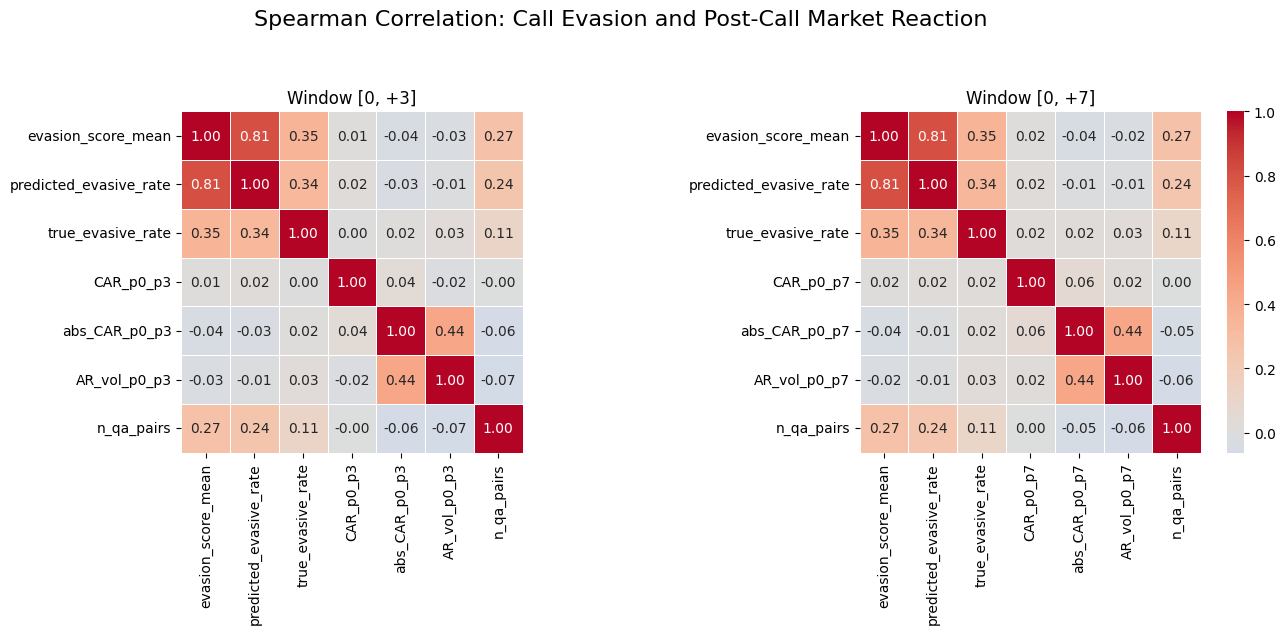

In [ ]:
fig, axes = plt.subplots(1, len(window_suffixes), figsize=(14, 6))

# Por si solo hubiera una ventana en el futuro
if len(window_suffixes) == 1:
    axes = [axes]

for ax, (t1, t2), suffix in zip(axes, event_windows, window_suffixes):
    corr_vars = [
        "evasion_score_mean",
        "predicted_evasive_rate",
        "true_evasive_rate",
        f"CAR_{suffix}",
        f"abs_CAR_{suffix}",
        f"AR_vol_{suffix}",
        "n_qa_pairs",
    ]
    
    corr_vars = [c for c in corr_vars if c in df_plot.columns]

    corr_df = df_plot.dropna(subset=corr_vars)[corr_vars].copy()
    corr = corr_df.corr(method="spearman")

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar=(ax == axes[-1]),
        ax=ax
    )
    
    ax.set_title(f"Window [{t1}, +{t2}]")

plt.suptitle(
    "Spearman Correlation: Call Evasion and Post-Call Market Reaction",
    y=1.05,
    fontsize=16
)

plt.tight_layout()
plt.show()

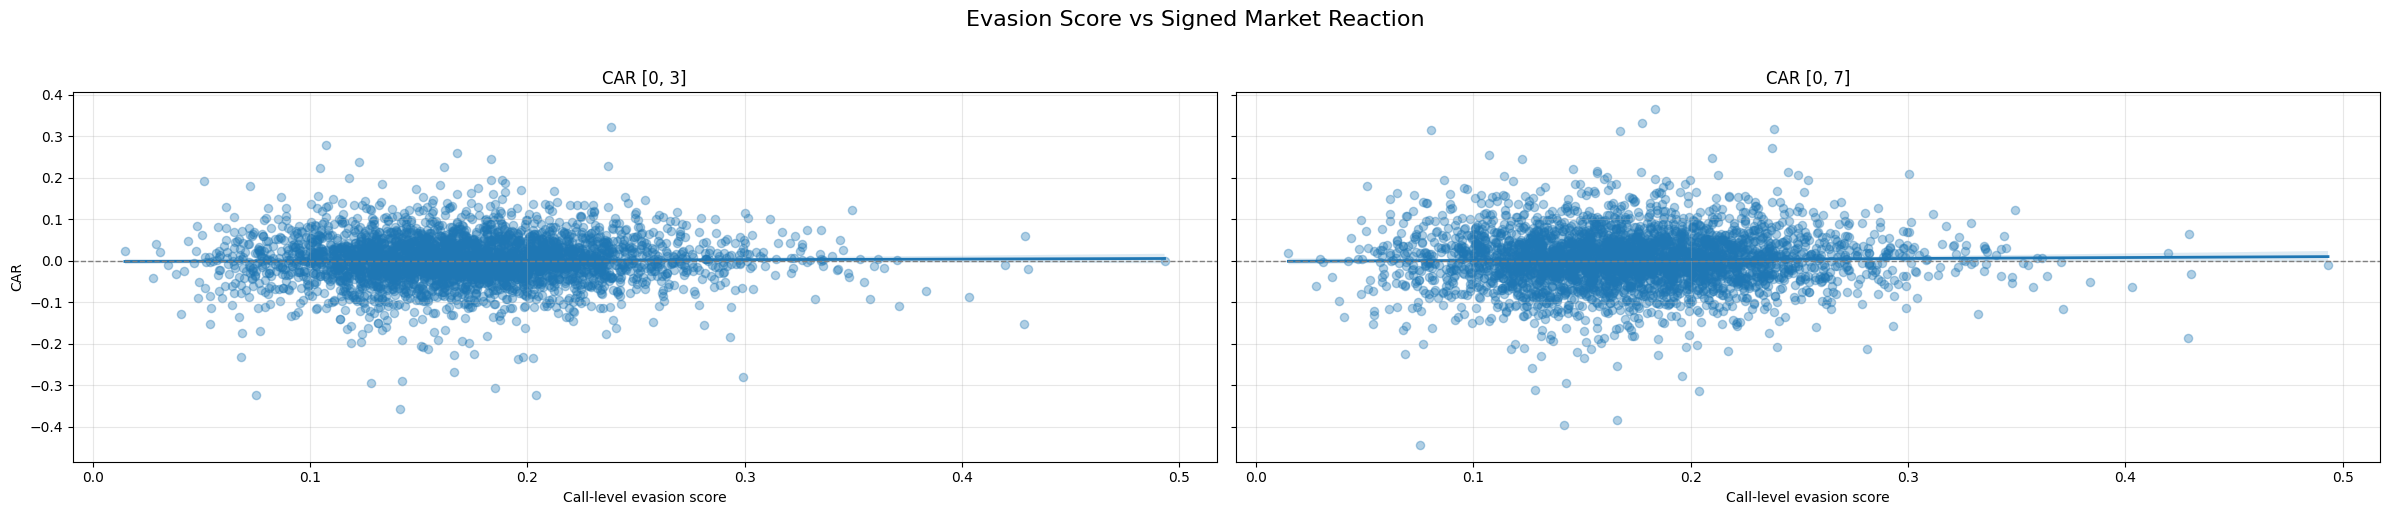

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 5), sharey=True)

for ax, (t1, t2), suffix in zip(axes, event_windows, window_suffixes):
    y_col = f"CAR_{suffix}"
    needed = ["evasion_score_mean", y_col]

    sub = df_plot.dropna(subset=needed).copy()

    sns.regplot(
        data=sub,
        x="evasion_score_mean",
        y=y_col,
        scatter_kws={"alpha": 0.35, "s": 35},
        line_kws={"linewidth": 2},
        ax=ax
    )

    ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.set_title(f"CAR [{t1}, {t2}]")
    ax.set_xlabel("Call-level evasion score")
    ax.set_ylabel("CAR" if ax == axes[0] else "")
    ax.grid(alpha=0.3)

plt.suptitle("Evasion Score vs Signed Market Reaction", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

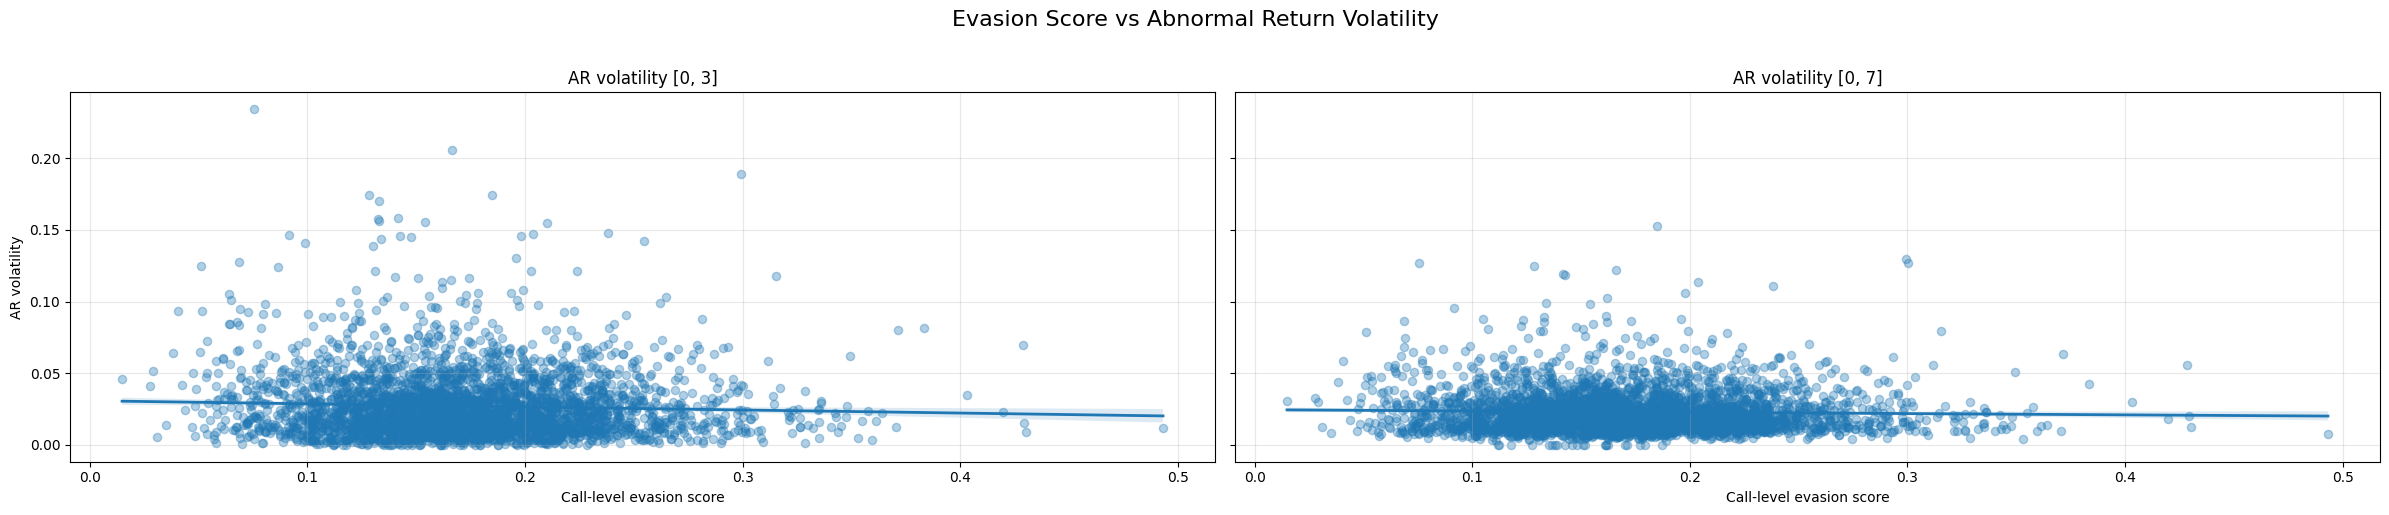

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 5), sharey=True)

for ax, (t1, t2), suffix in zip(axes, event_windows, window_suffixes):
    y_col = f"AR_vol_{suffix}"
    needed = ["evasion_score_mean", y_col]

    sub = df_plot.dropna(subset=needed).copy()

    sns.regplot(
        data=sub,
        x="evasion_score_mean",
        y=y_col,
        scatter_kws={"alpha": 0.35, "s": 35},
        line_kws={"linewidth": 2},
        ax=ax
    )

    ax.set_title(f"AR volatility [{t1}, {t2}]")
    ax.set_xlabel("Call-level evasion score")
    ax.set_ylabel("AR volatility" if ax == axes[0] else "")
    ax.grid(alpha=0.3)

plt.suptitle("Evasion Score vs Abnormal Return Volatility", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

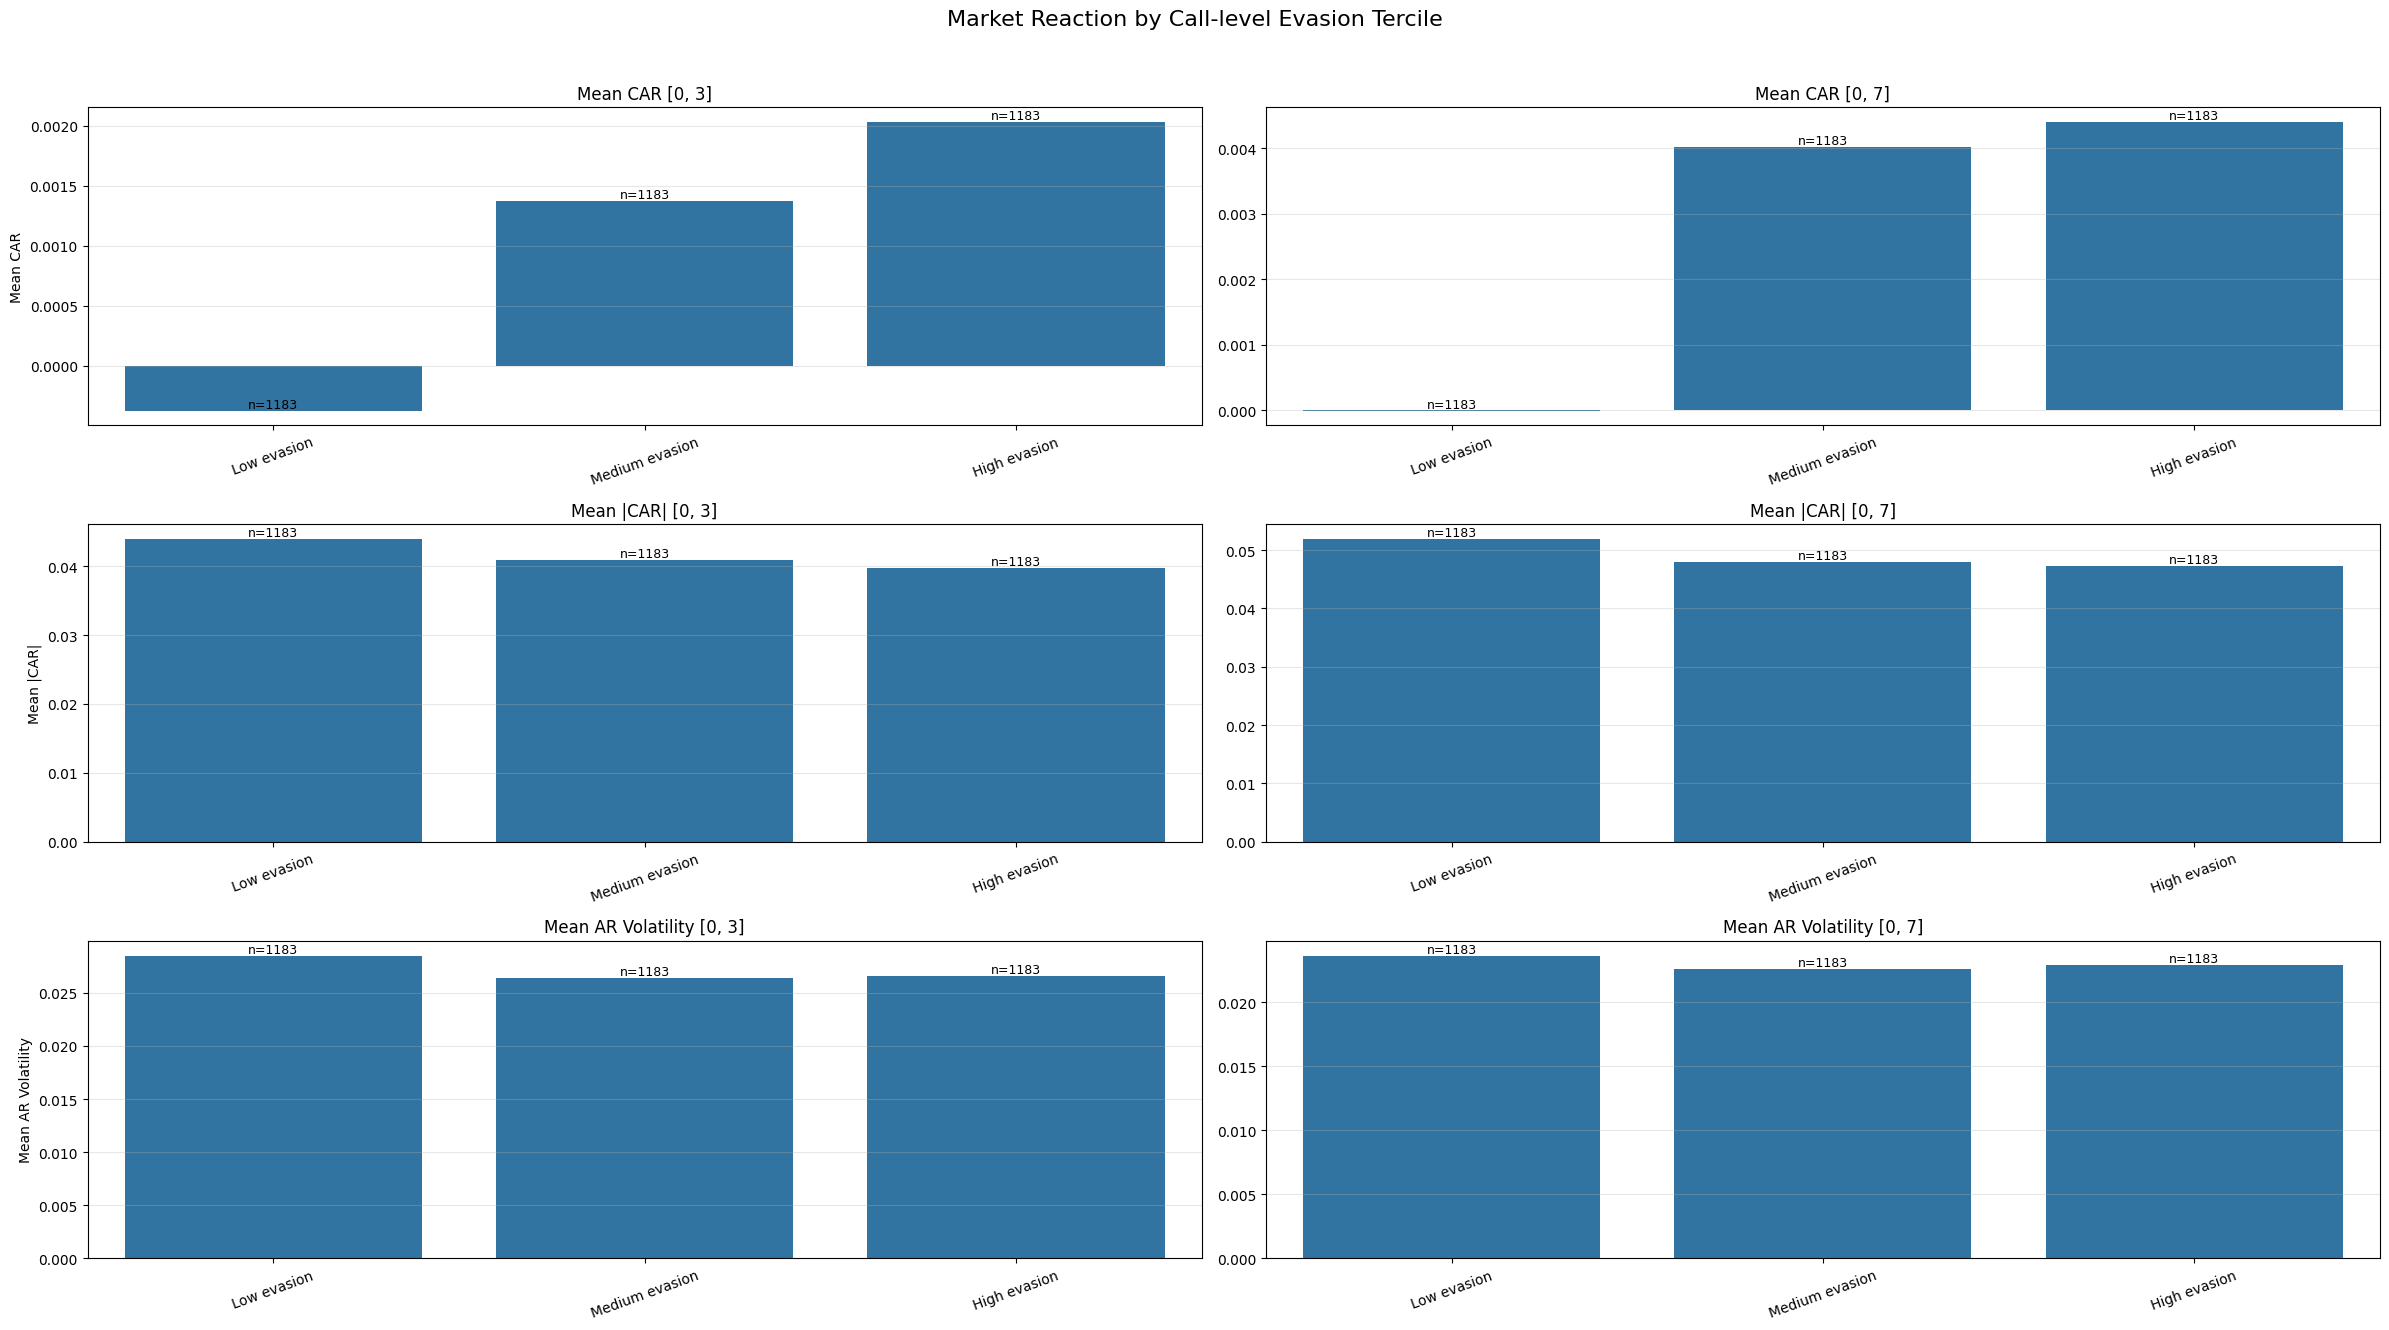

In [ ]:
# Crear buckets una sola vez
df_bars = df_plot.dropna(subset=["evasion_score_mean"]).copy()

df_bars["evasion_bucket"] = pd.qcut(
    df_bars["evasion_score_mean"],
    q=3,
    labels=["Low evasion", "Medium evasion", "High evasion"],
    duplicates="drop"
)

fig, axes = plt.subplots(3, 2, figsize=(24, 13), sharex=False)

row_metrics = [
    ("CAR", "Mean CAR"),
    ("abs_CAR", "Mean |CAR|"),
    ("AR_vol", "Mean AR Volatility")
]

for col_idx, ((t1, t2), suffix) in enumerate(zip(event_windows, window_suffixes)):
    metric_map = {
        "CAR": f"CAR_{suffix}",
        "abs_CAR": f"abs_CAR_{suffix}",
        "AR_vol": f"AR_vol_{suffix}",
    }

    bucket_summary = (
        df_bars
        .groupby("evasion_bucket", observed=True)
        .agg(
            n_events=("ticker", "count"),
            mean_CAR=(metric_map["CAR"], "mean"),
            mean_abs_CAR=(metric_map["abs_CAR"], "mean"),
            mean_AR_vol=(metric_map["AR_vol"], "mean"),
        )
        .reset_index()
    )

    y_cols = ["mean_CAR", "mean_abs_CAR", "mean_AR_vol"]

    for row_idx, (y_col, (metric_key, metric_title)) in enumerate(zip(y_cols, row_metrics)):
        ax = axes[row_idx, col_idx]

        sns.barplot(
            data=bucket_summary,
            x="evasion_bucket",
            y=y_col,
            ax=ax
        )

        ax.set_title(f"{metric_title} [{t1}, {t2}]")
        ax.set_xlabel("")
        ax.set_ylabel(metric_title if col_idx == 0 else "")
        ax.tick_params(axis="x", rotation=20)
        ax.grid(axis="y", alpha=0.3)

        # Añadir n encima
        for i, row in bucket_summary.iterrows():
            value = row[y_col]
            if pd.notna(value):
                ax.text(
                    i,
                    value,
                    f"n={int(row['n_events'])}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

plt.suptitle("Market Reaction by Call-level Evasion Tercile", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
all_bucket_summaries = []

for (t1, t2), suffix in zip(event_windows, window_suffixes):
    tmp = df_plot.dropna(subset=["evasion_score_mean"]).copy()

    tmp["evasion_bucket"] = pd.qcut(
        tmp["evasion_score_mean"],
        q=3,
        labels=["Low evasion", "Medium evasion", "High evasion"],
        duplicates="drop"
    )

    summary = (
        tmp
        .groupby("evasion_bucket", observed=True)
        .agg(
            n_events=("ticker", "count"),
            mean_evasion=("evasion_score_mean", "mean"),
            mean_CAR=(f"CAR_{suffix}", "mean"),
            mean_abs_CAR=(f"abs_CAR_{suffix}", "mean"),
            mean_AR_vol=(f"AR_vol_{suffix}", "mean"),
        )
        .reset_index()
    )

    summary["window"] = f"[{t1}, {t2}]"
    all_bucket_summaries.append(summary)

bucket_summary_all = pd.concat(all_bucket_summaries, ignore_index=True)
display(bucket_summary_all)

,evasion_bucket,n_events,mean_evasion,mean_CAR,mean_abs_CAR,mean_AR_vol,window
0,Low evasion,1183,0.116134,-0.000374,0.043936,0.028487,"[0, 3]"
1,Medium evasion,1183,0.169432,0.001374,0.040890,0.026370,"[0, 3]"
2,High evasion,1183,0.231456,0.002033,0.039766,0.026566,"[0, 3]"
3,Low evasion,1183,0.116134,-0.000004,0.051896,0.023635,"[0, 7]"
4,Medium evasion,1183,0.169432,0.004017,0.047939,0.022597,"[0, 7]"
5,High evasion,1183,0.231456,0.004404,0.047276,0.022882,"[0, 7]"
